In [1]:
import warnings
warnings.filterwarnings("ignore")

import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# Beautiful Theme
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="viridis")

# High Quality Images
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["figure.dpi"] = 300

# Create Graph Folder
os.makedirs("../graphs", exist_ok=True)

print("Setup Completed Successfully")

Setup Completed Successfully


In [2]:
data = pd.read_csv("../data/iris.csv")

data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print("Shape :", data.shape)

print("\nColumns")
print(data.columns)

print("\nData Types")
print(data.dtypes)

print("\nInformation")
data.info()

Shape : (150, 5)

Columns
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Data Types
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
data.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [5]:
print("Duplicate Rows :", data.duplicated().sum())

Duplicate Rows : 3


In [6]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


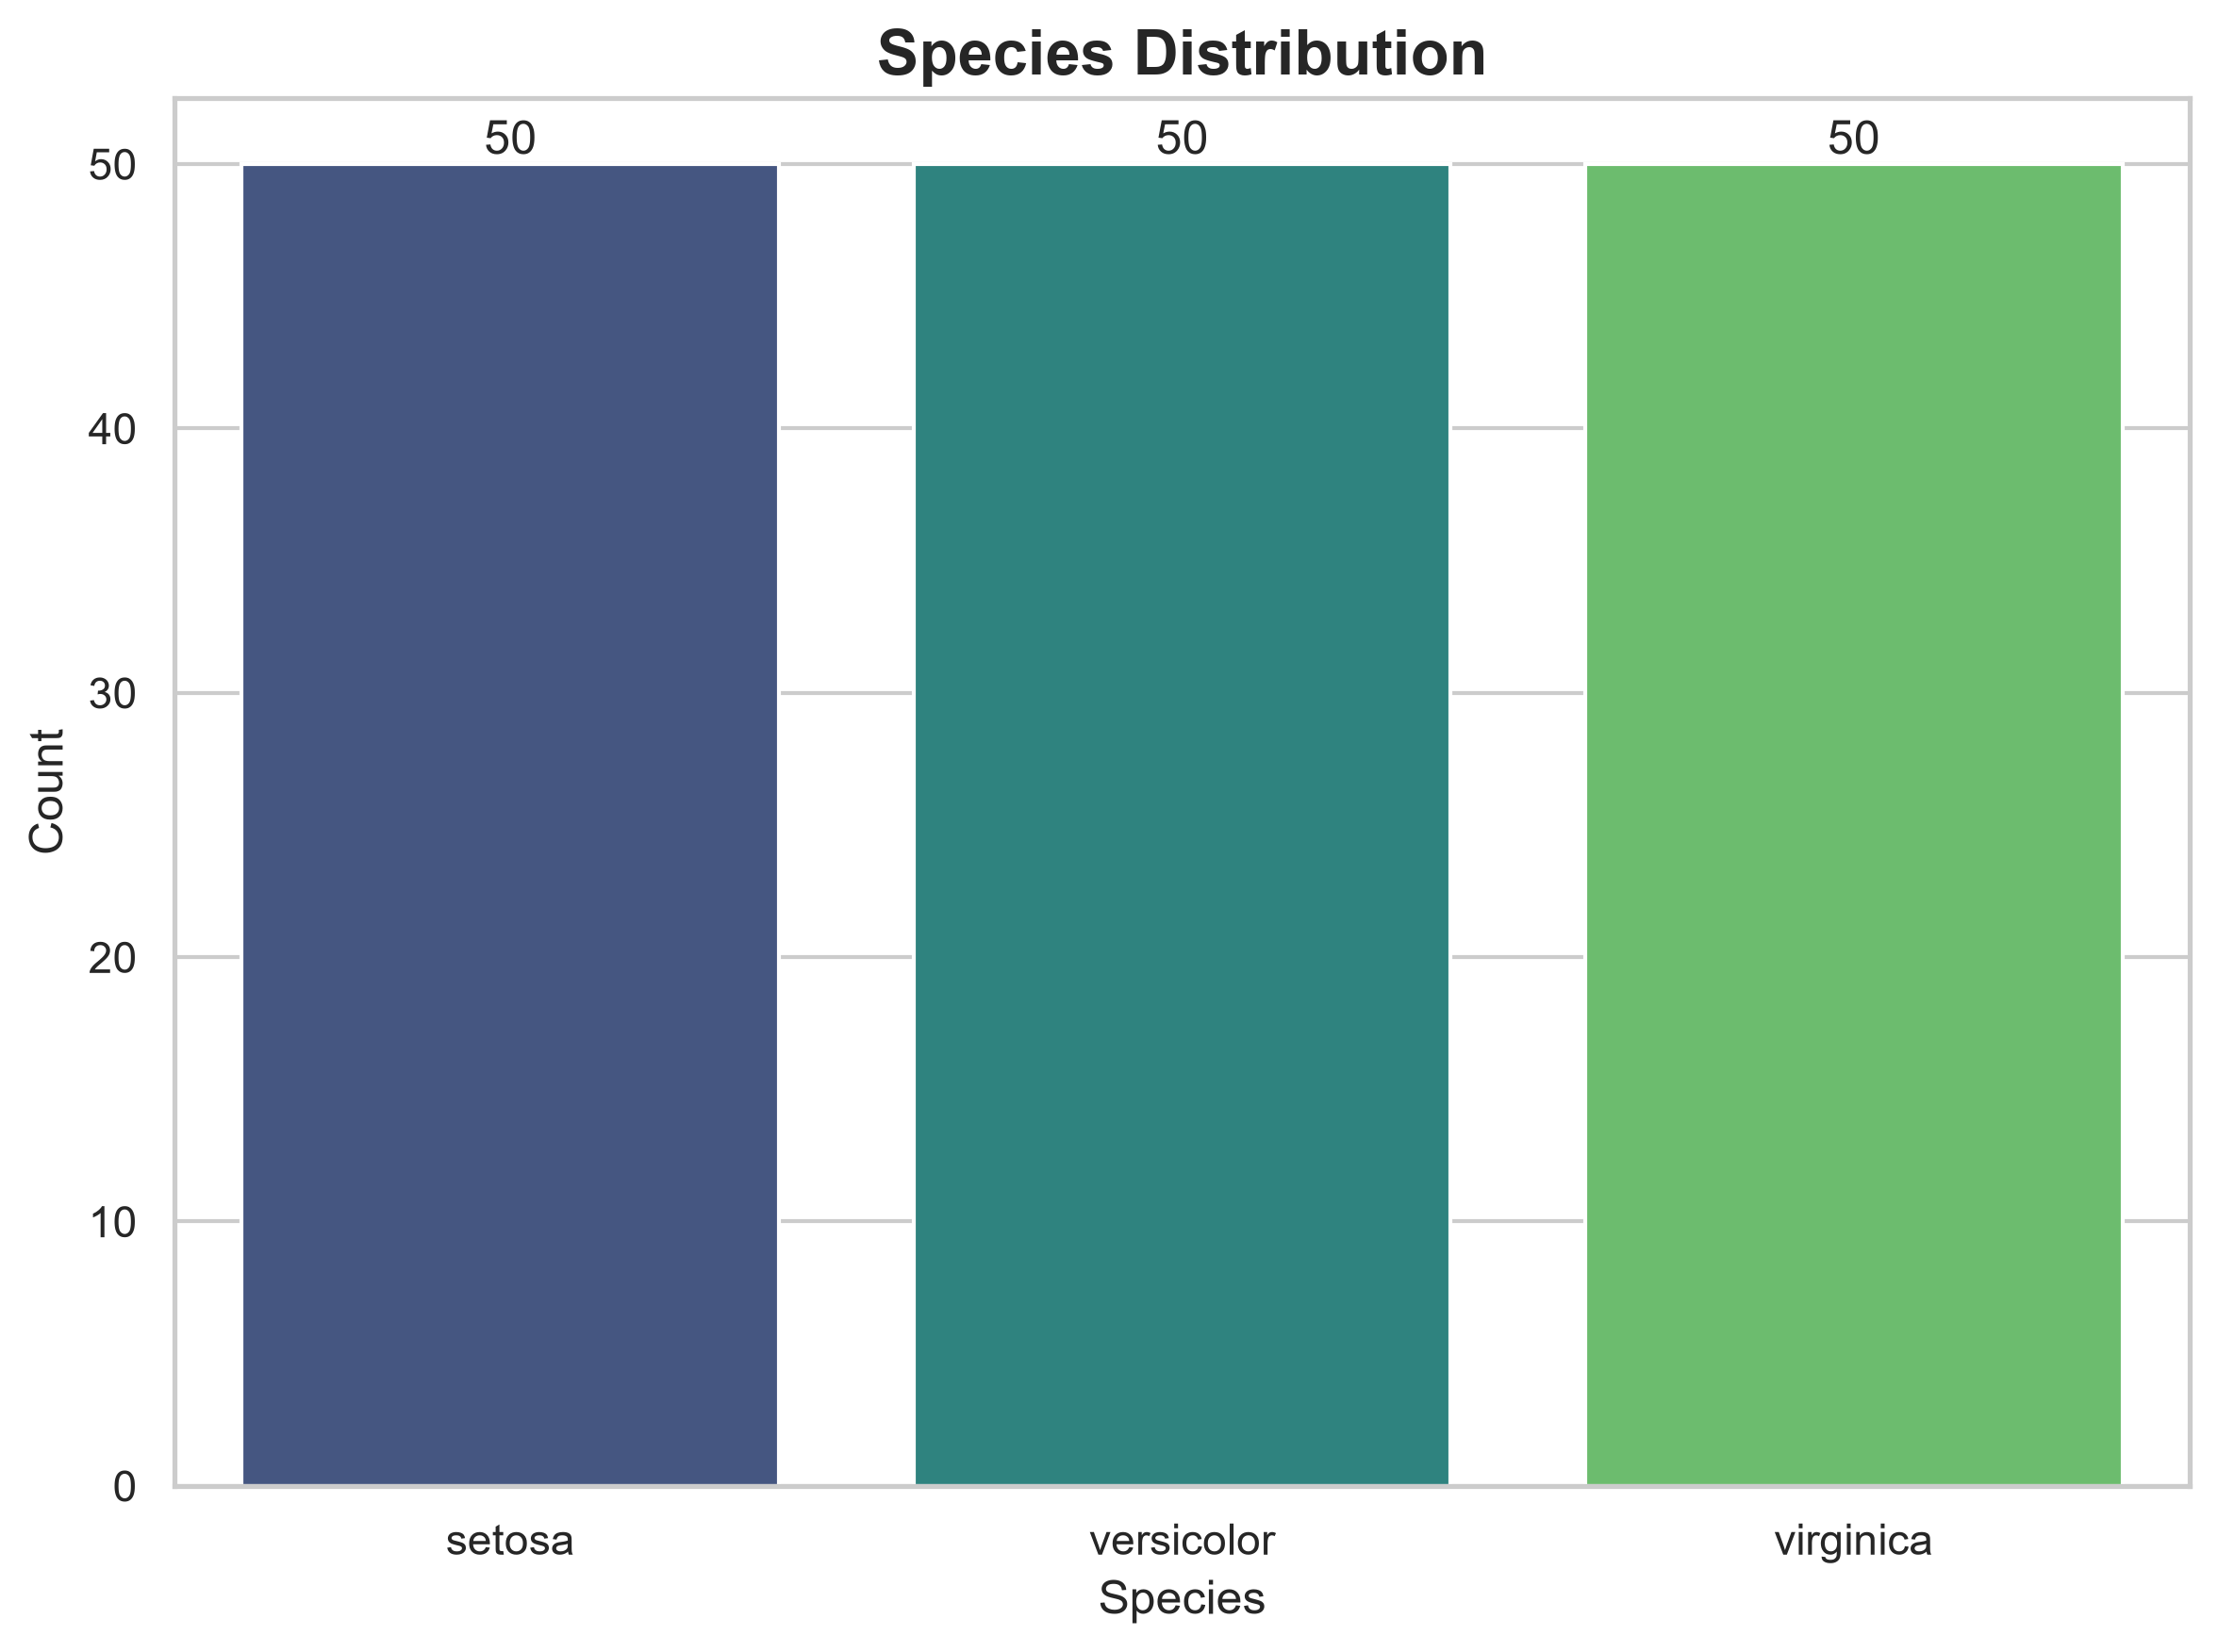

In [7]:
plt.figure(figsize=(8,6))

ax = sns.countplot(
    data=data,
    x="species",
    palette="viridis"
)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Species Distribution",fontsize=16,fontweight="bold")
plt.xlabel("Species")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../graphs/species_distribution.png",dpi=300)

plt.show()

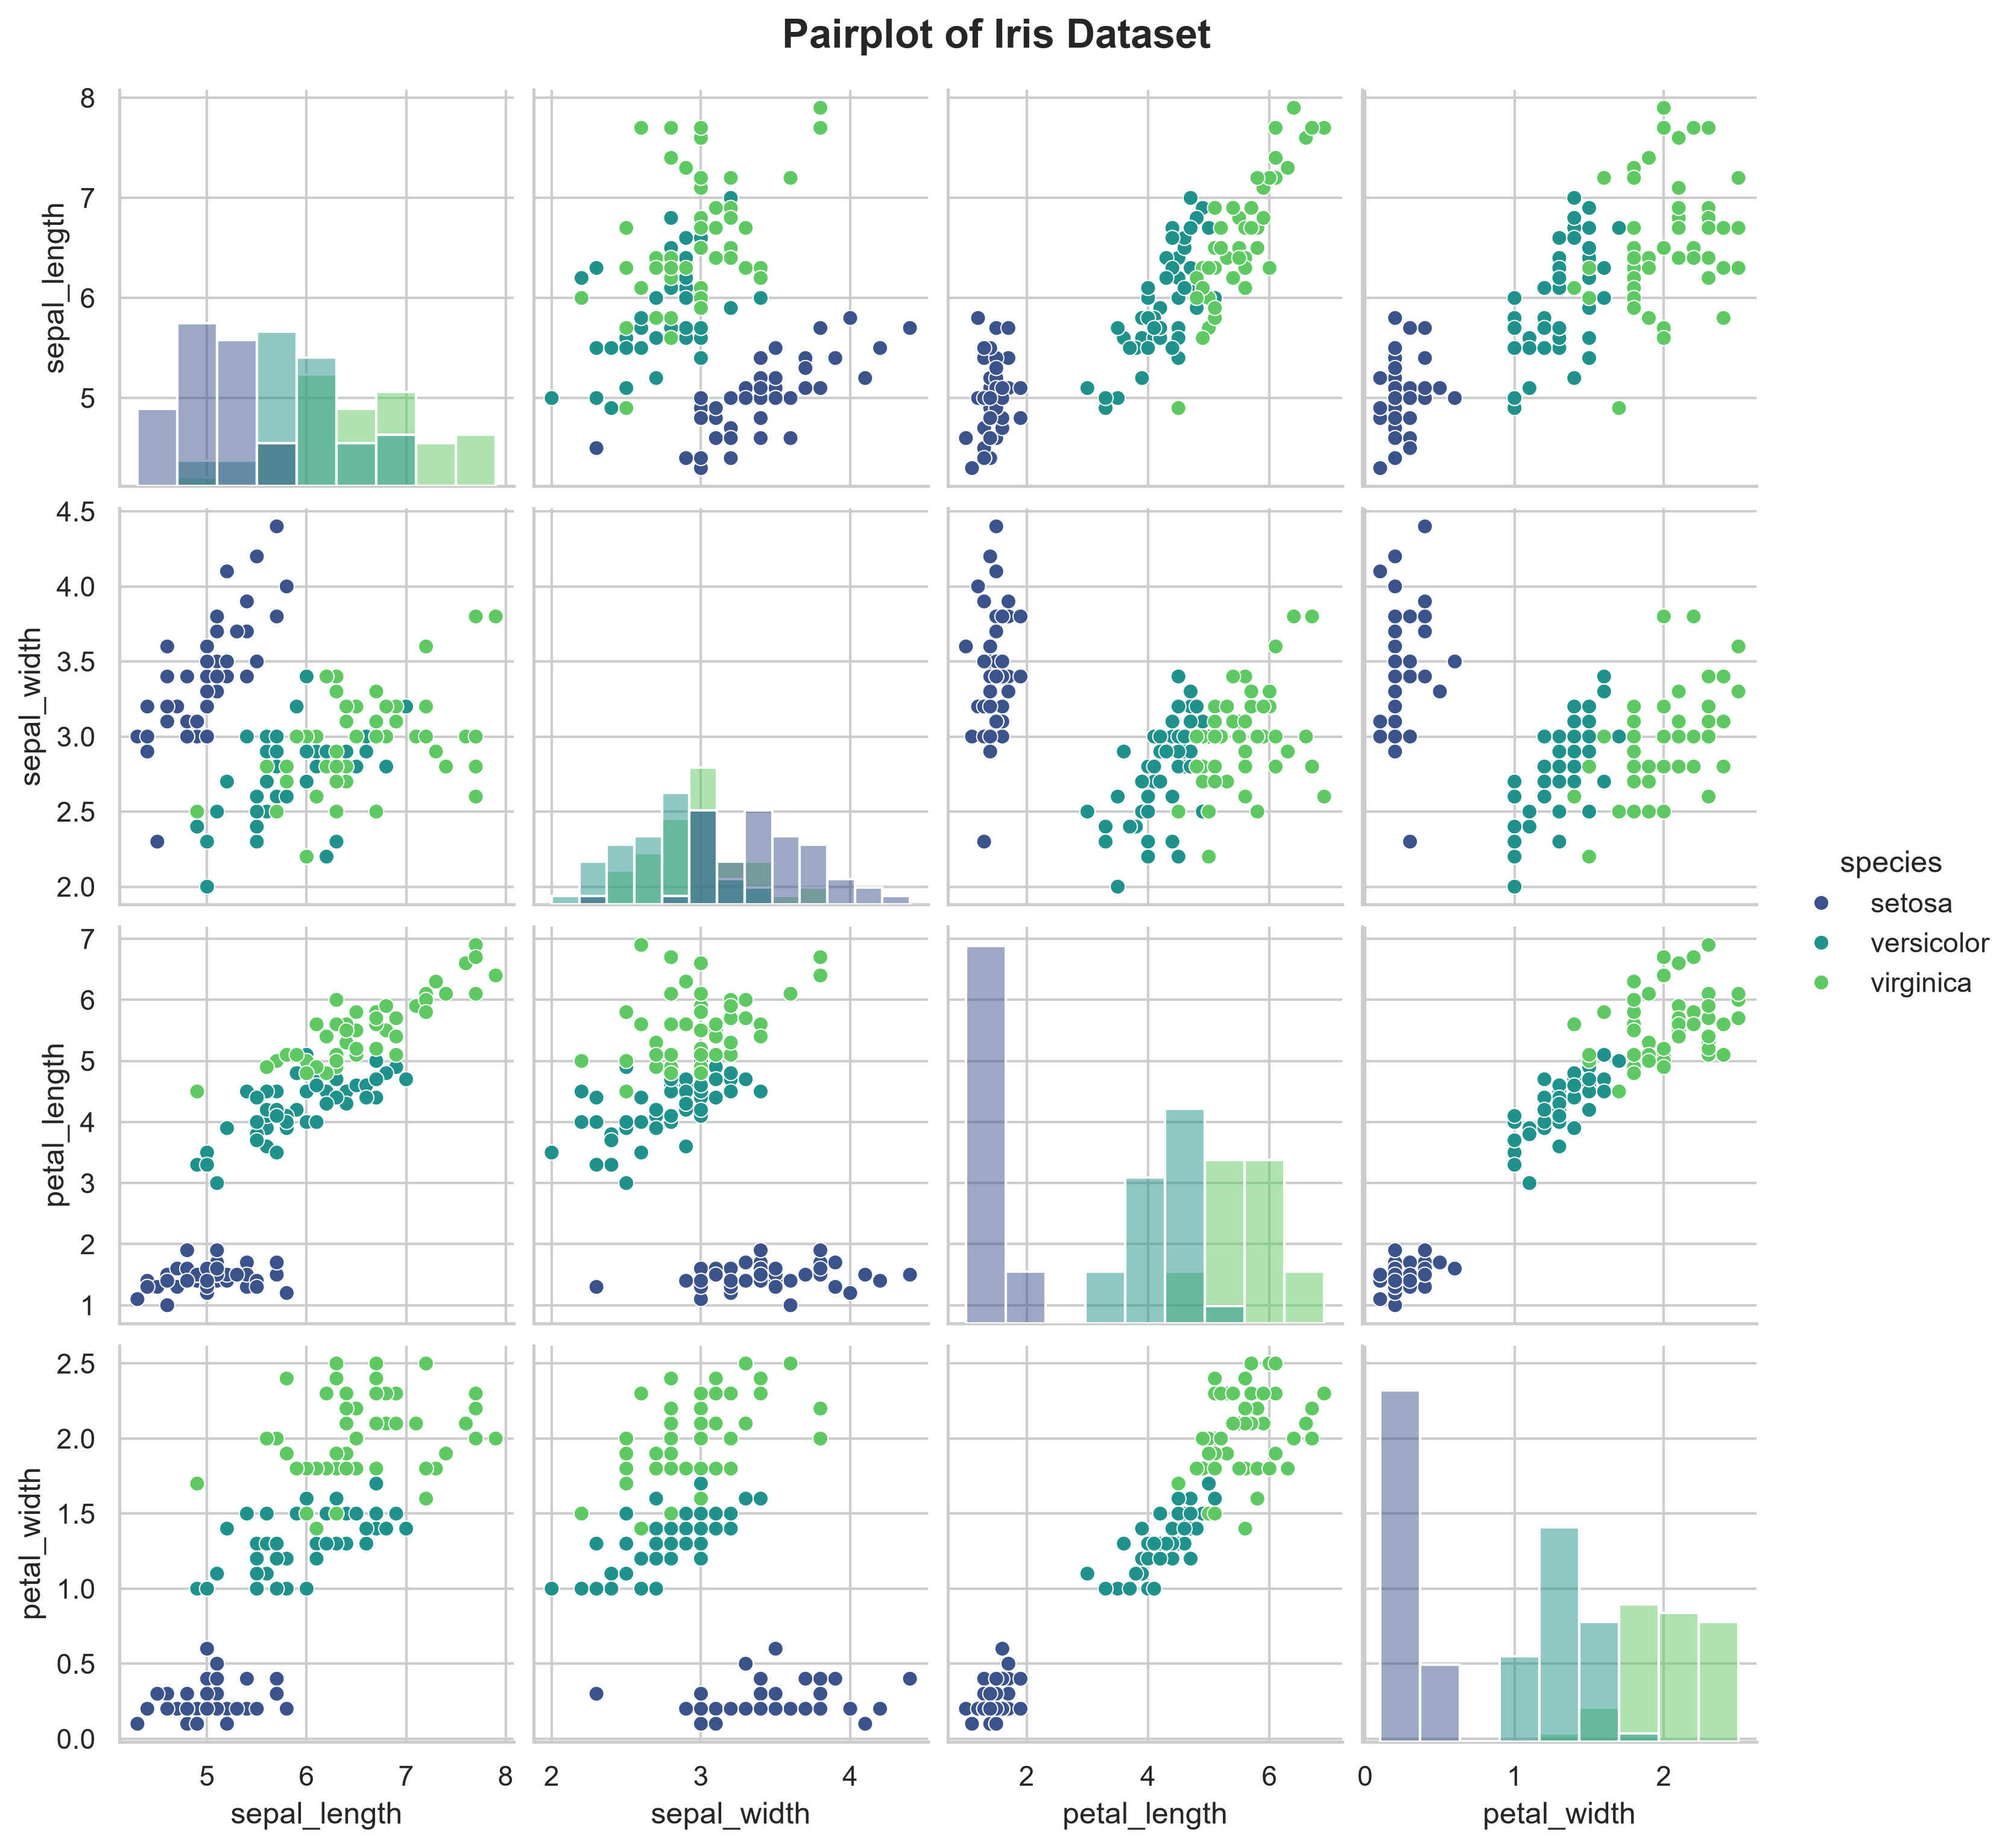

In [8]:
pair = sns.pairplot(
    data,
    hue="species",
    palette="viridis",
    diag_kind="hist"
)

pair.fig.suptitle(
    "Pairplot of Iris Dataset",
    y=1.02,
    fontsize=16,
    fontweight="bold"
)

pair.savefig("../graphs/pairplot.png",dpi=300)

plt.show()

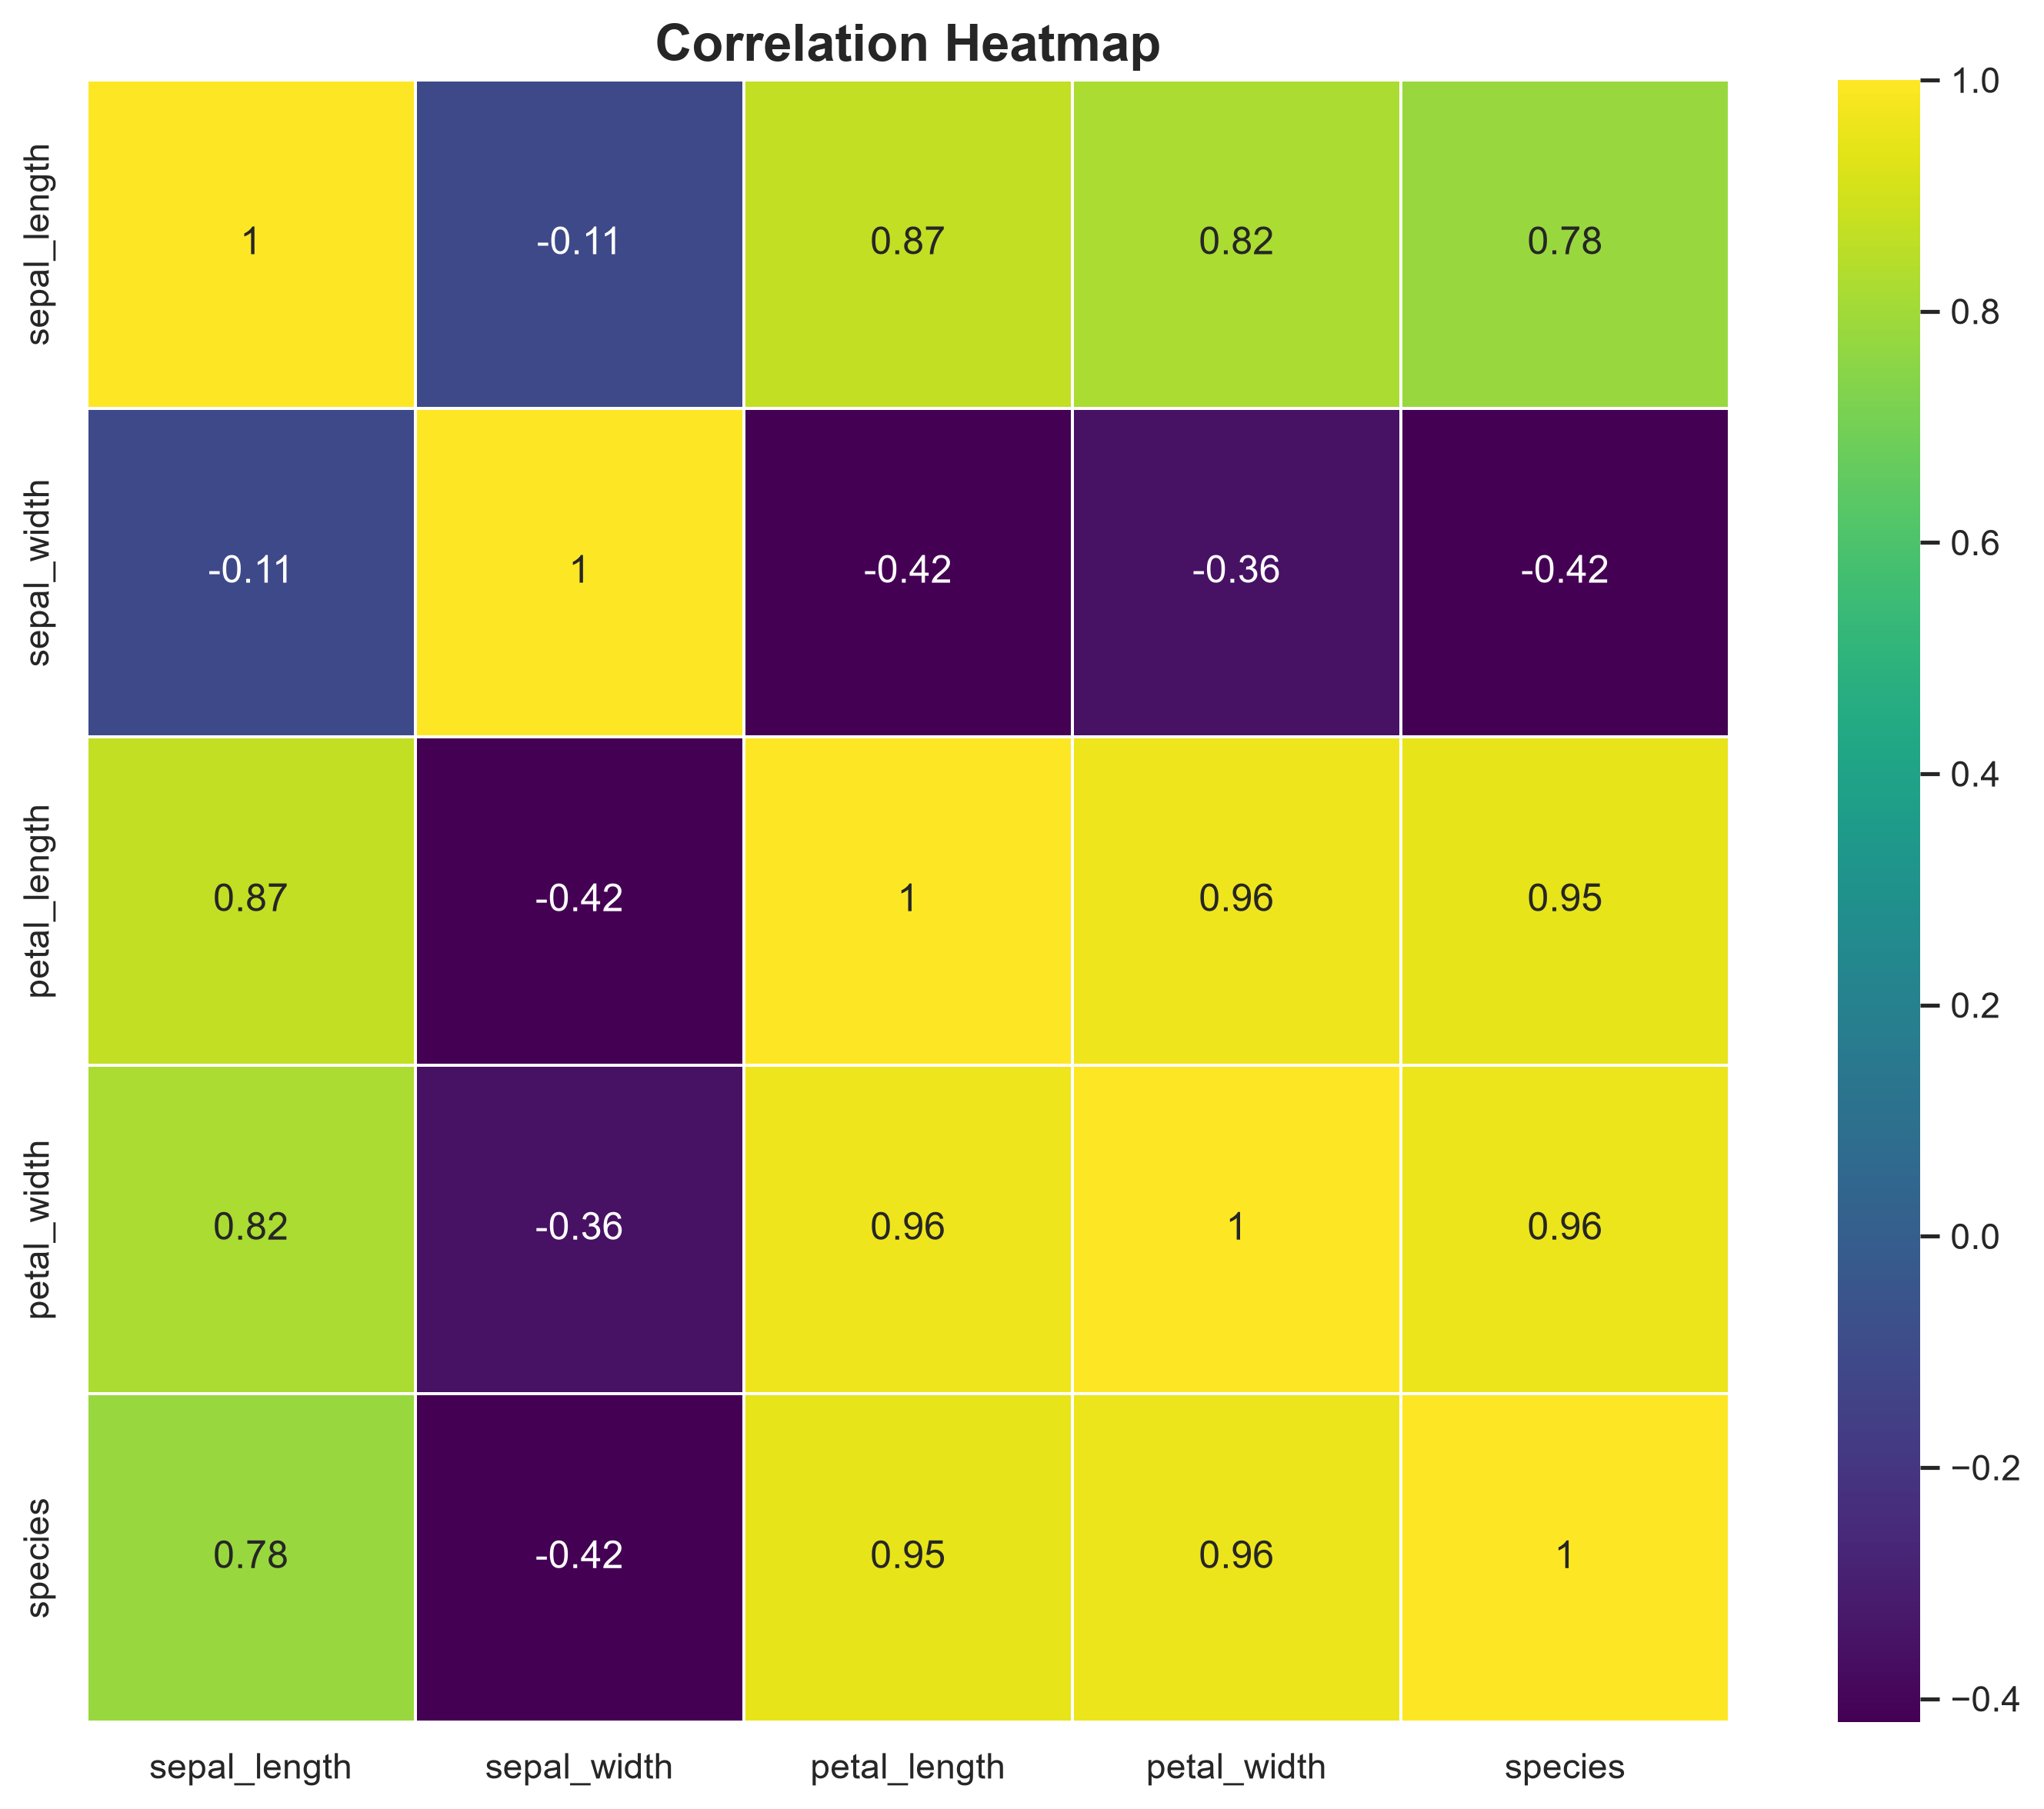

In [9]:
encoder = LabelEncoder()

temp = data.copy()

temp["species"] = encoder.fit_transform(temp["species"])

plt.figure(figsize=(10,8))

sns.heatmap(
    temp.corr(),
    annot=True,
    cmap="viridis",
    linewidths=.5,
    square=True
)

plt.title(
    "Correlation Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig("../graphs/heatmap.png",dpi=300)

plt.show()

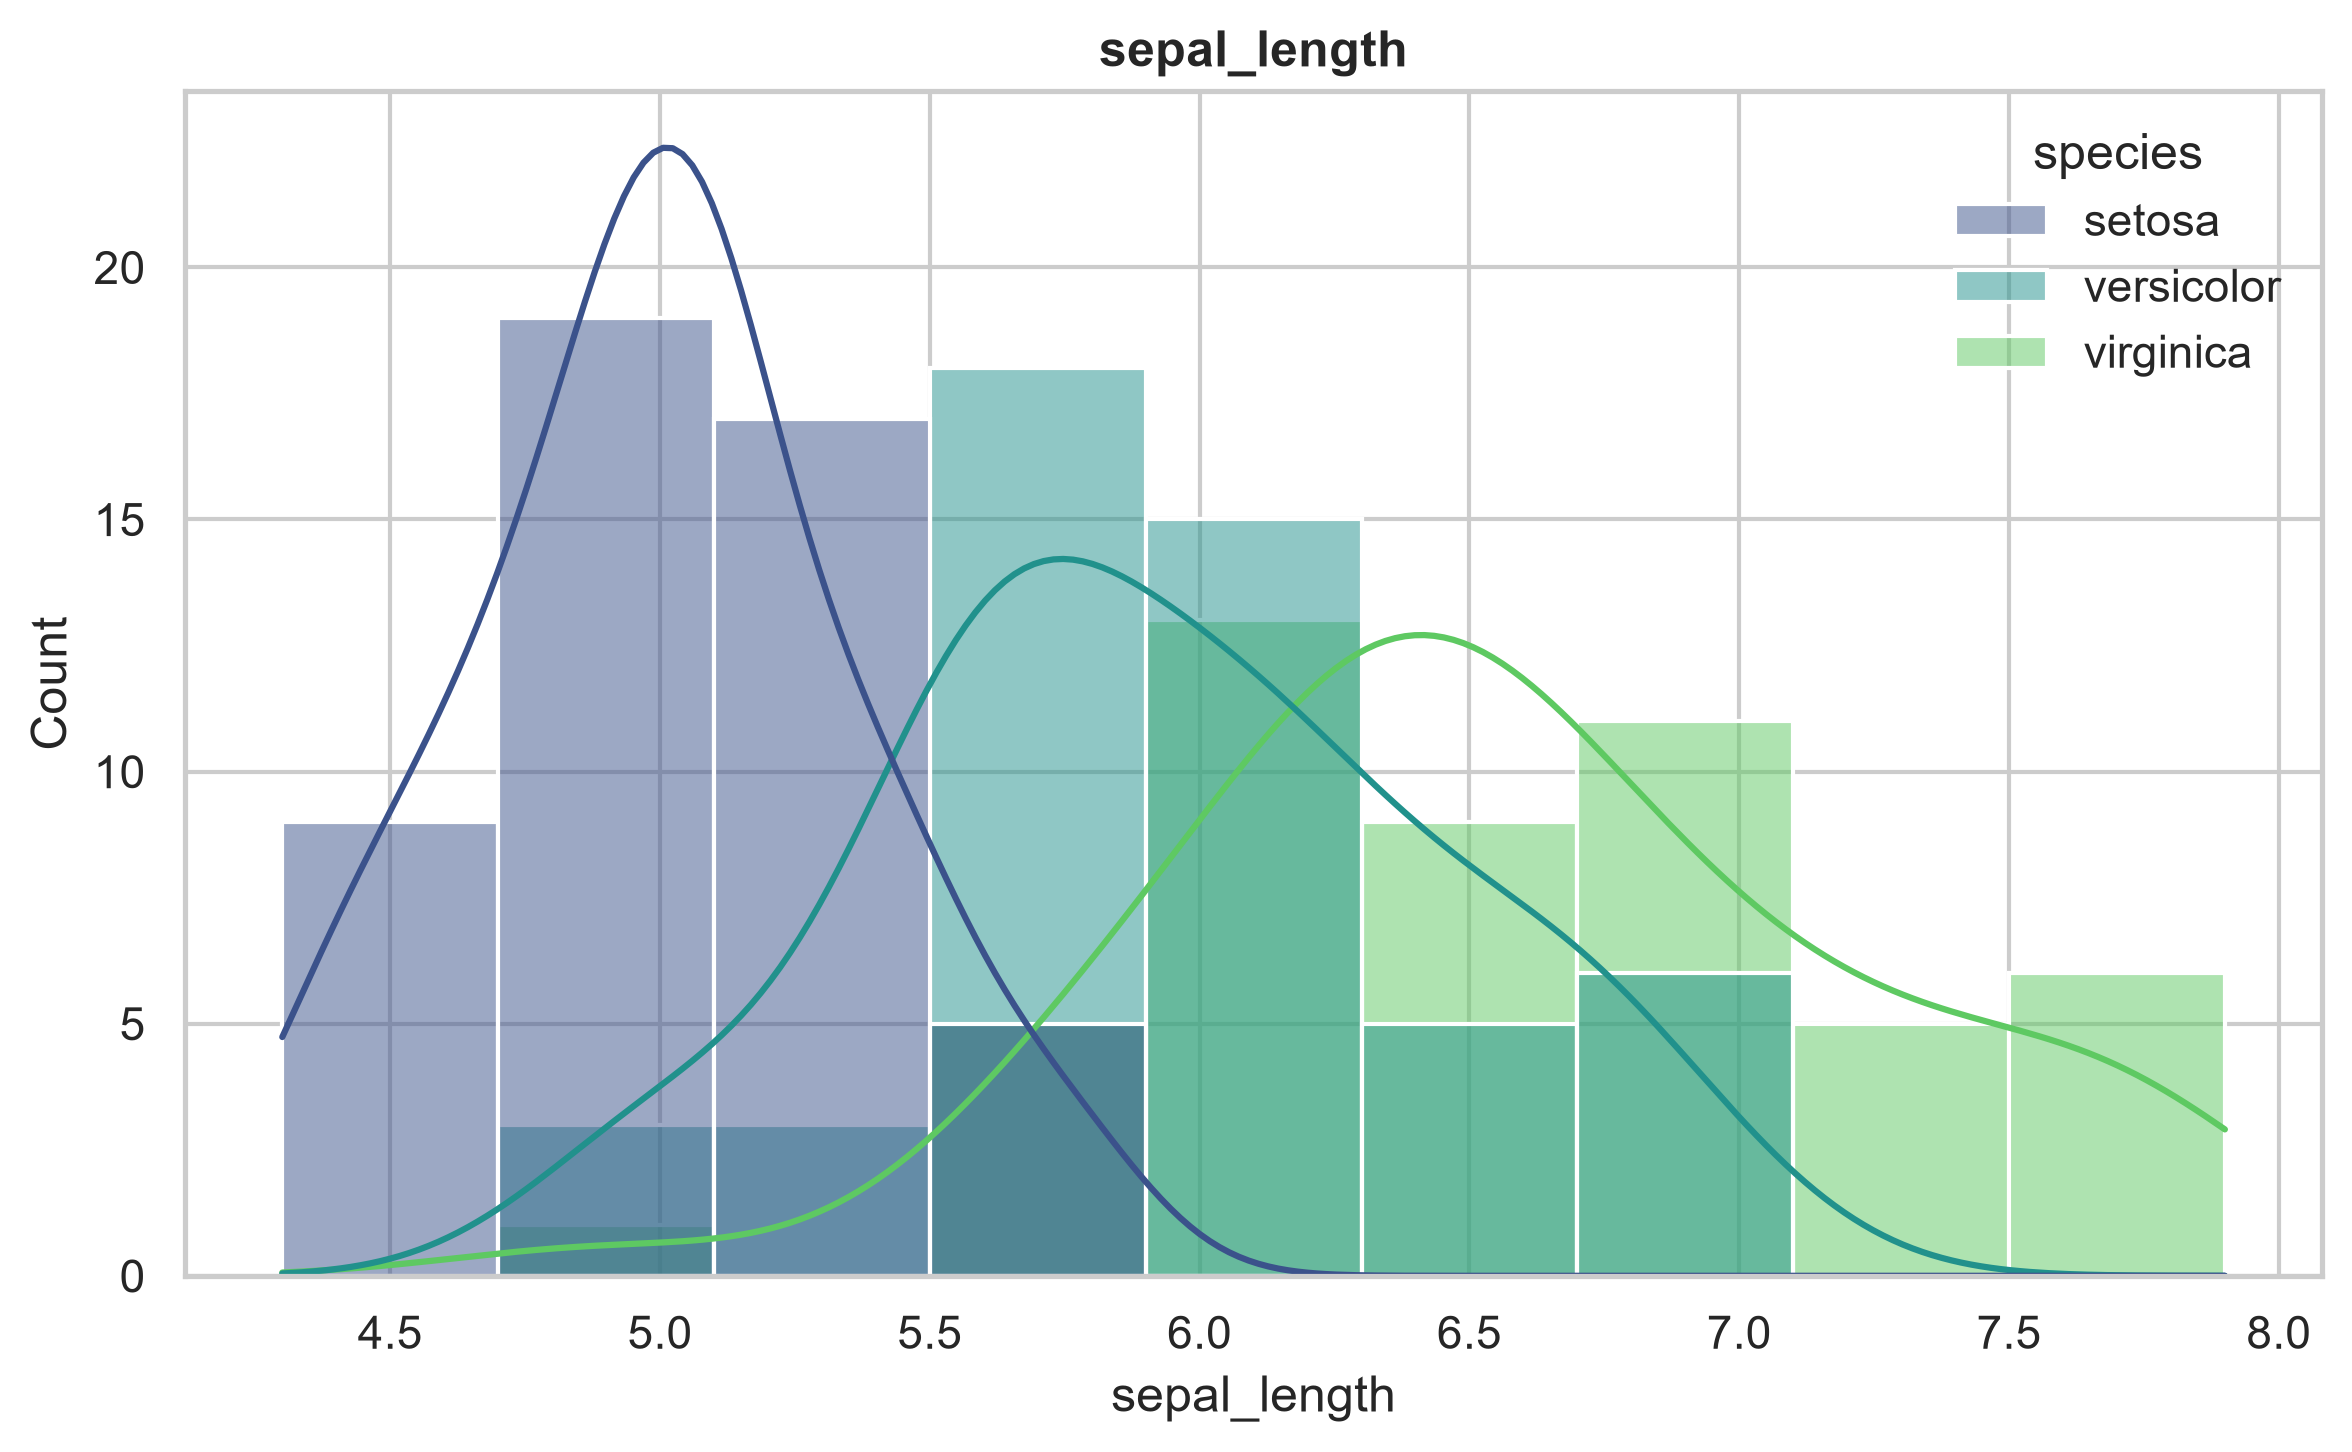

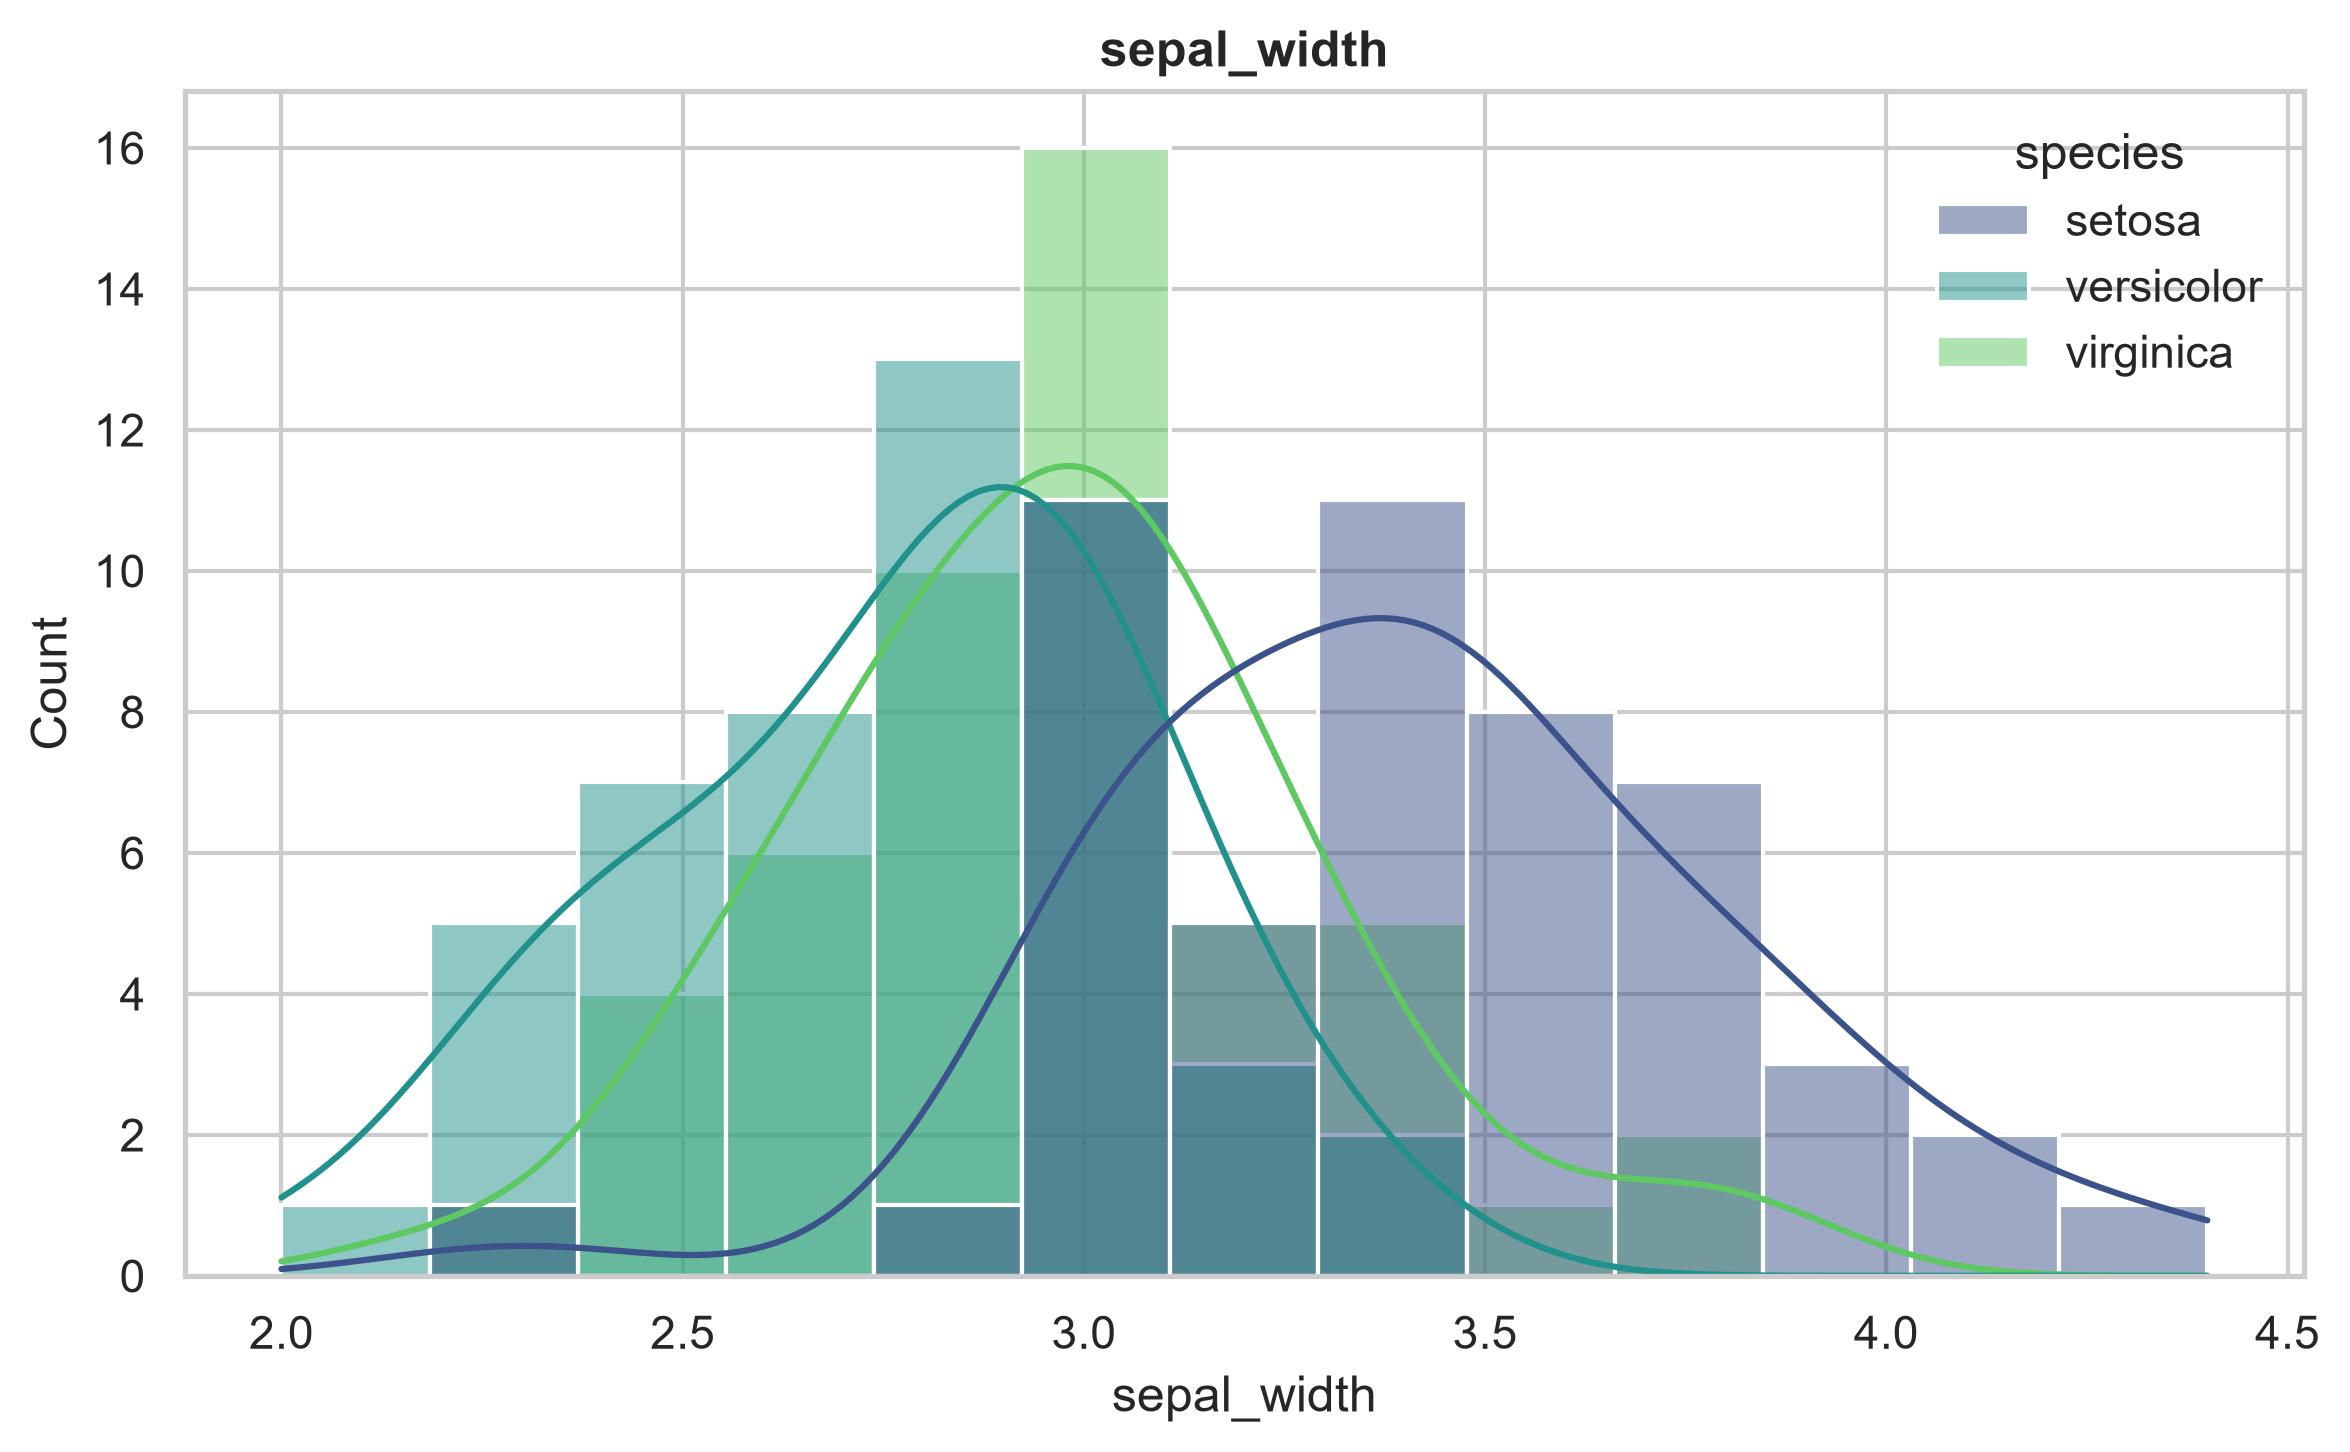

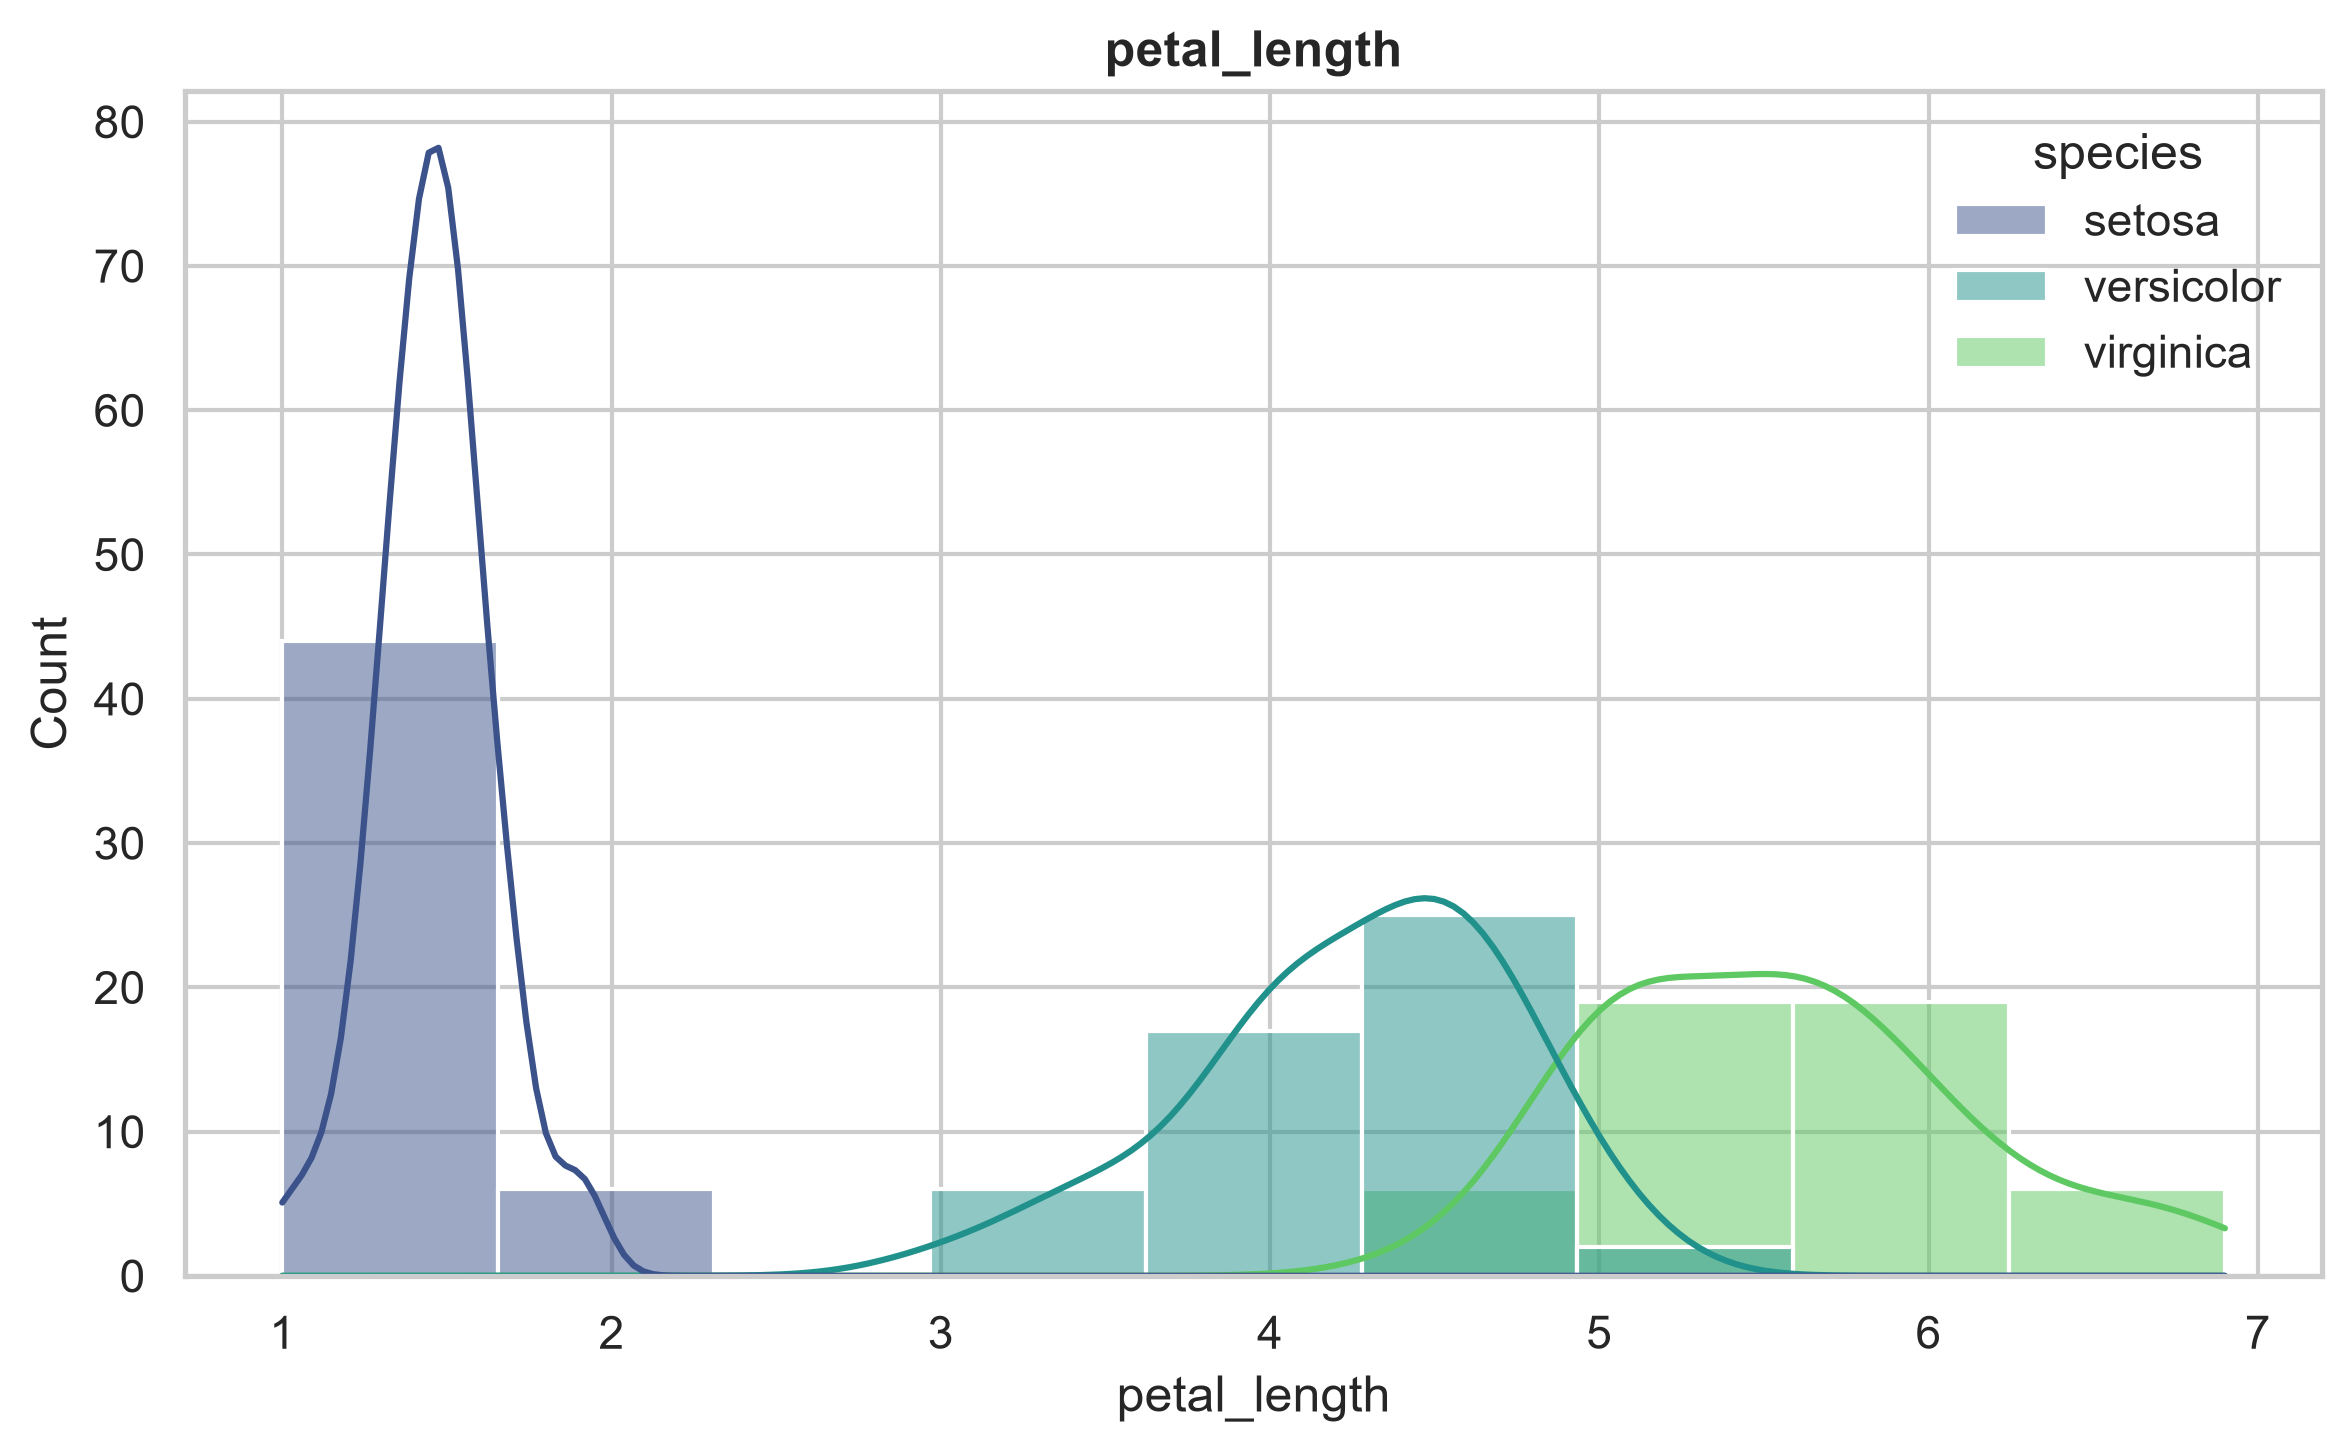

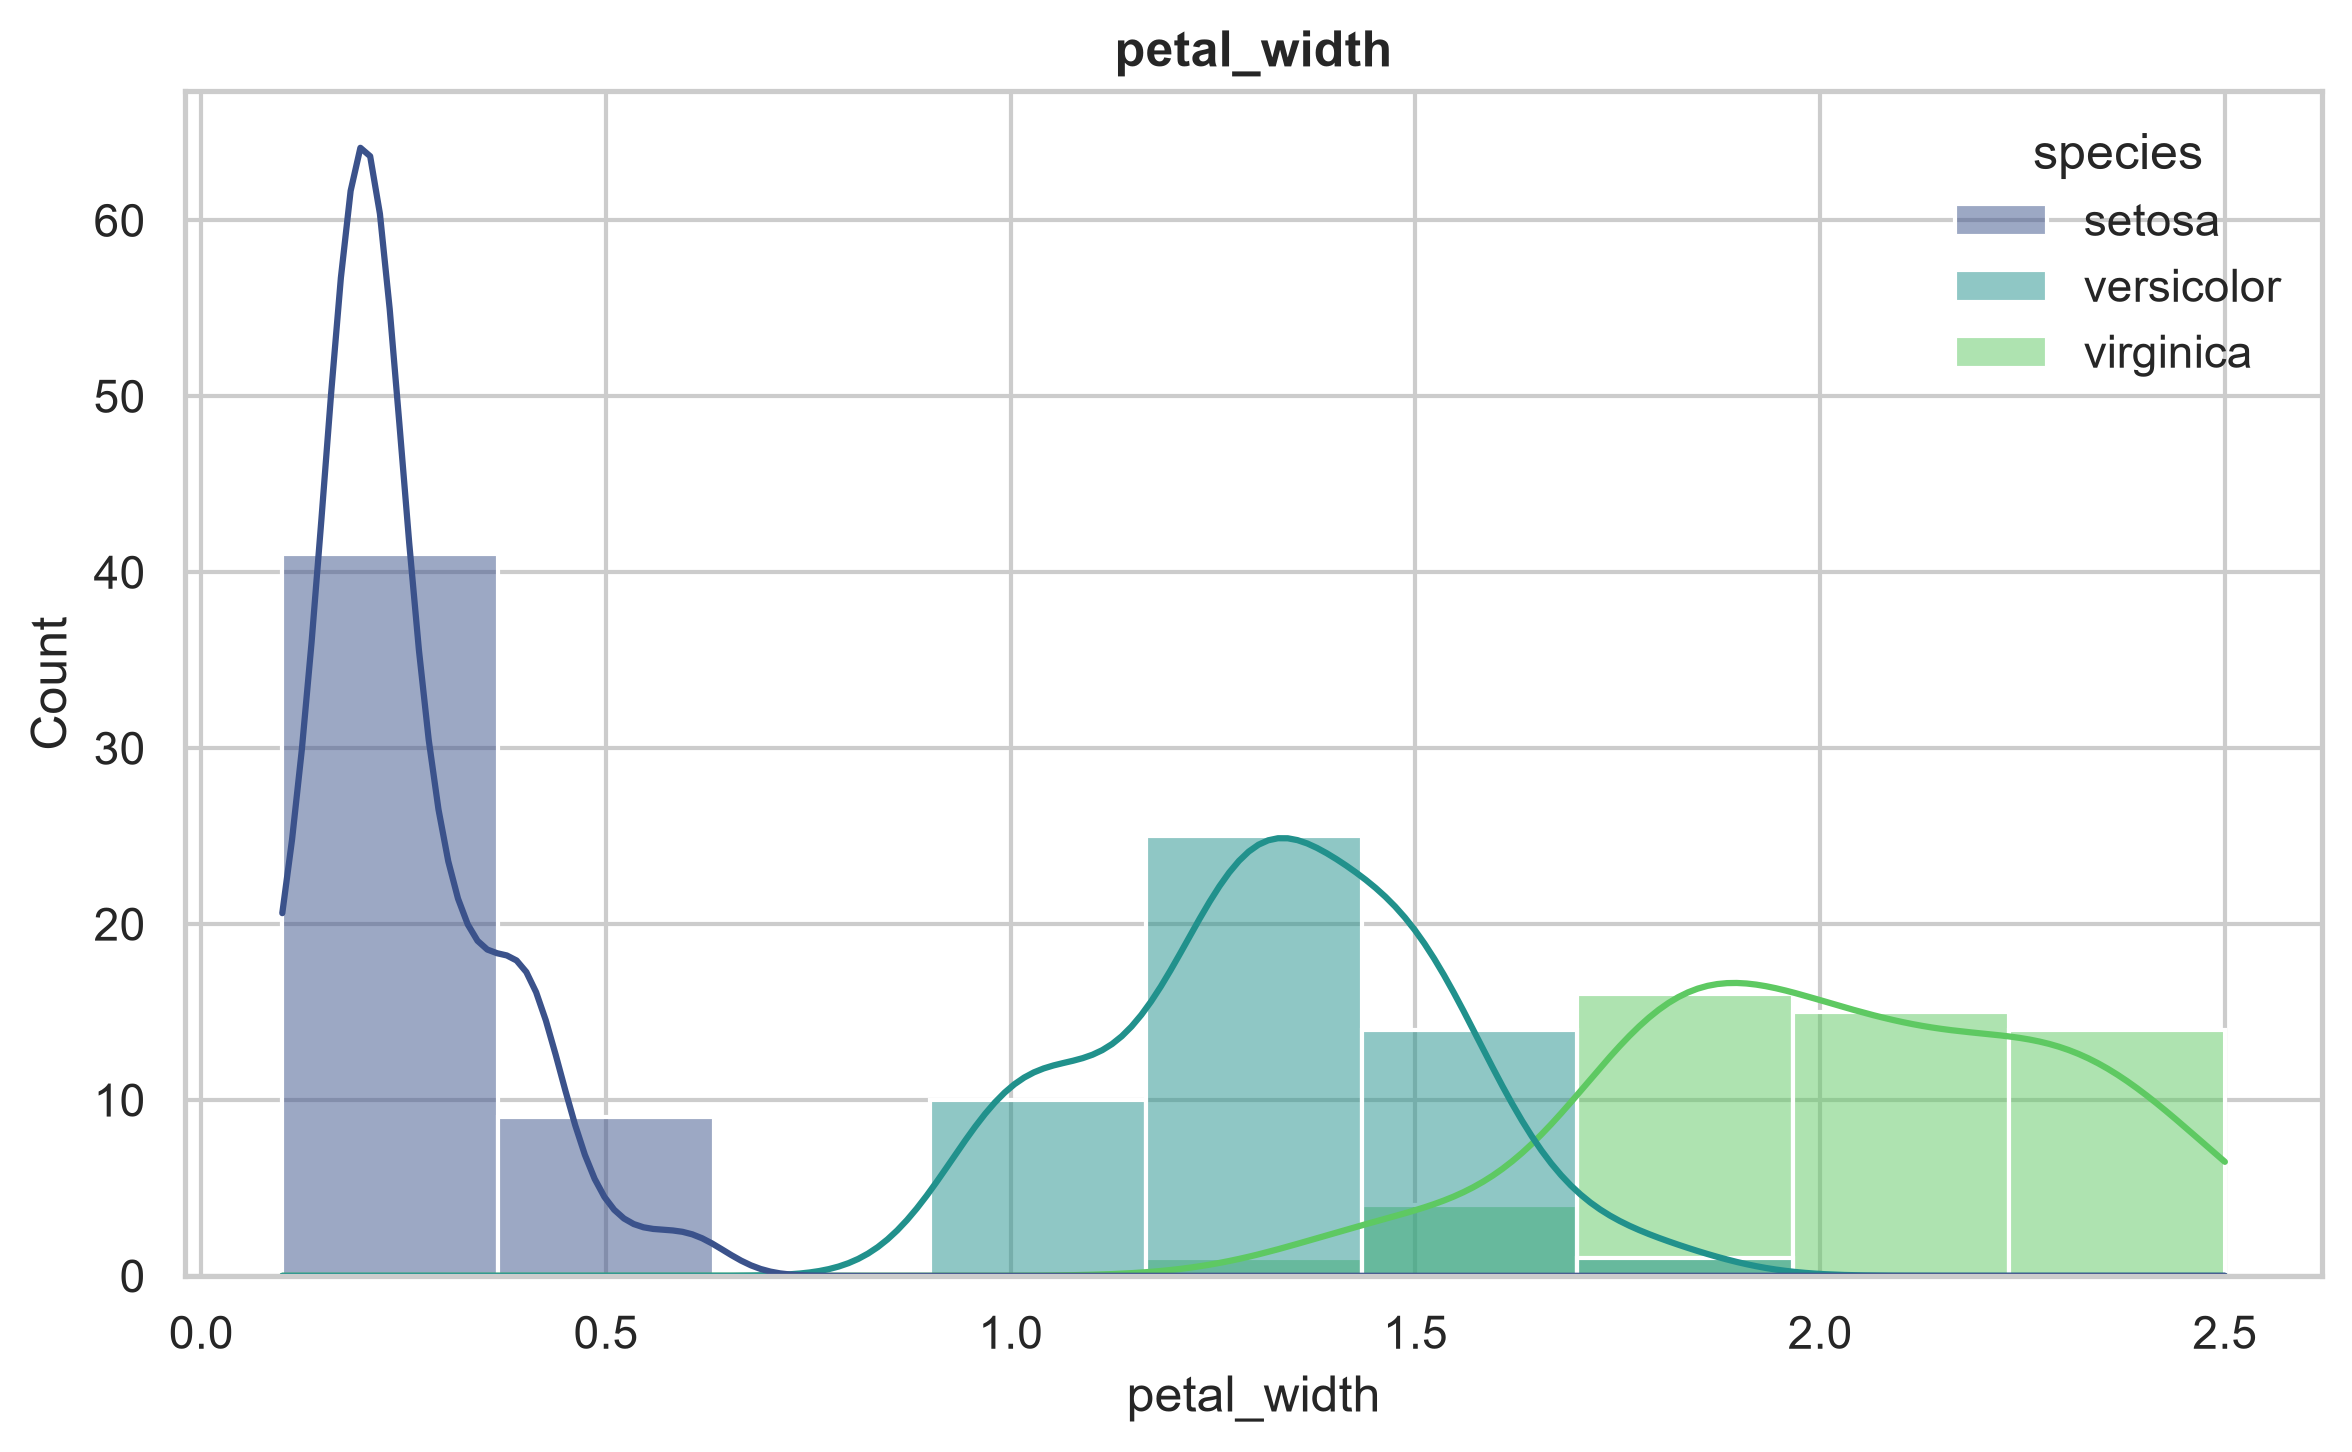

In [10]:
features = data.columns[:-1]

for feature in features:

    plt.figure(figsize=(8,5))

    sns.histplot(
        data=data,
        x=feature,
        hue="species",
        kde=True,
        palette="viridis"
    )

    plt.title(feature,fontweight="bold")

    plt.tight_layout()

    plt.savefig(f"../graphs/{feature}_histogram.png",dpi=300)

    plt.show()

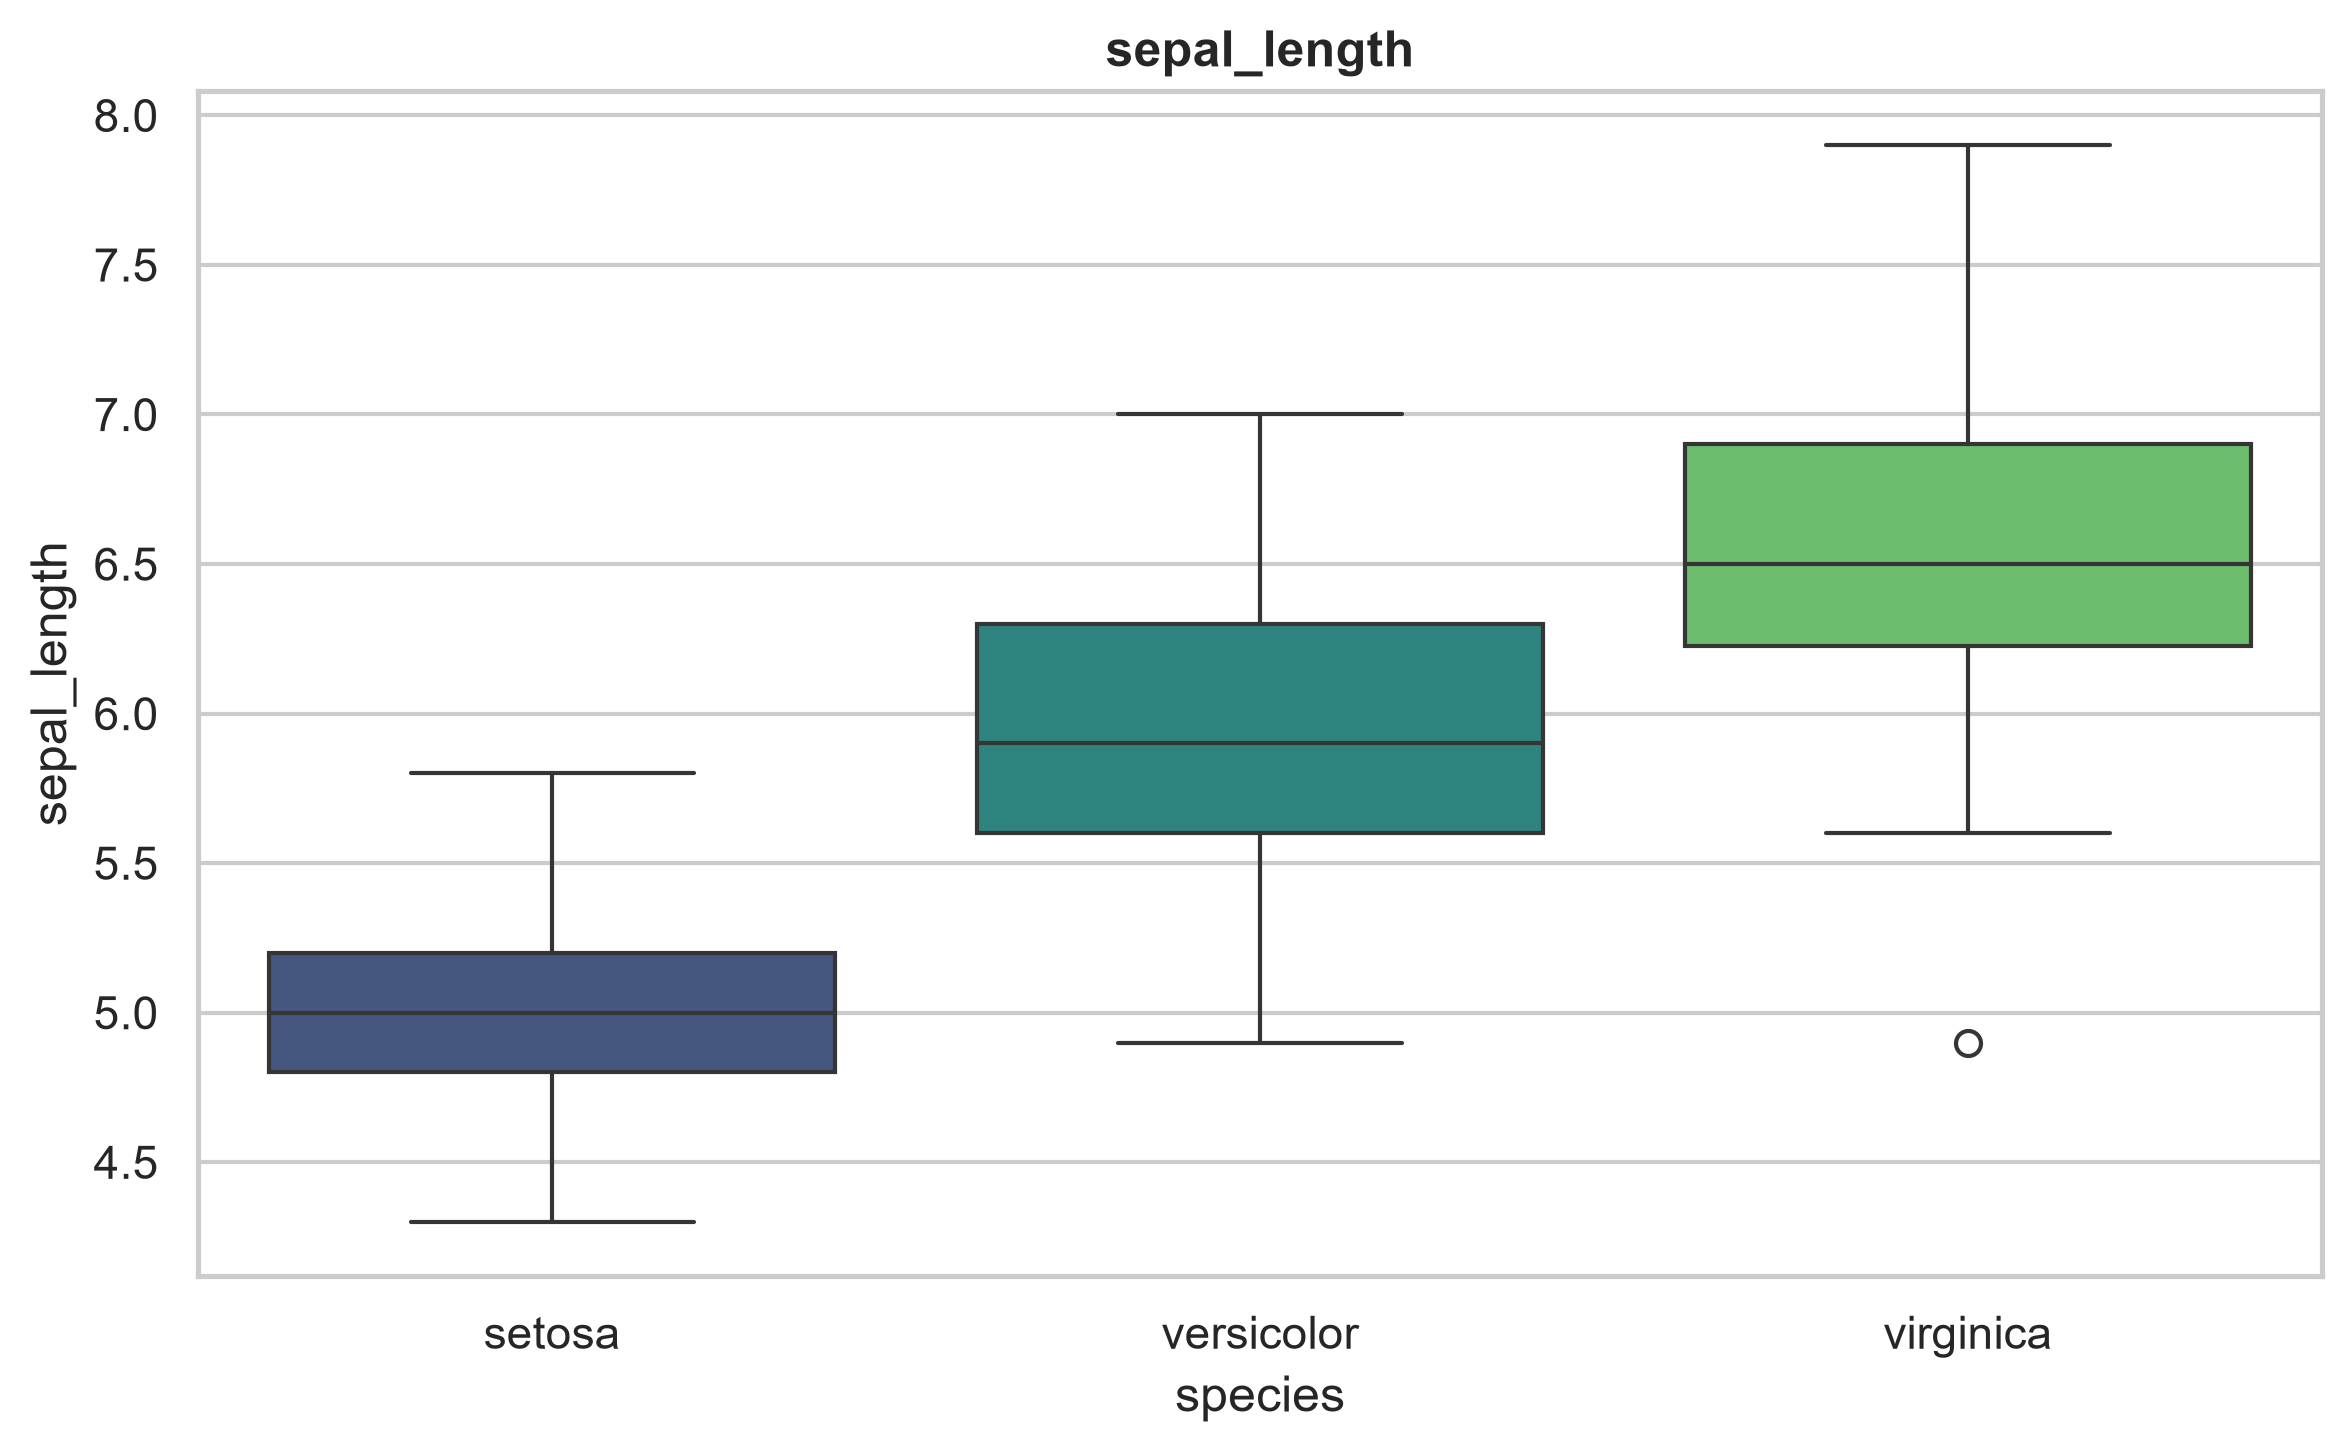

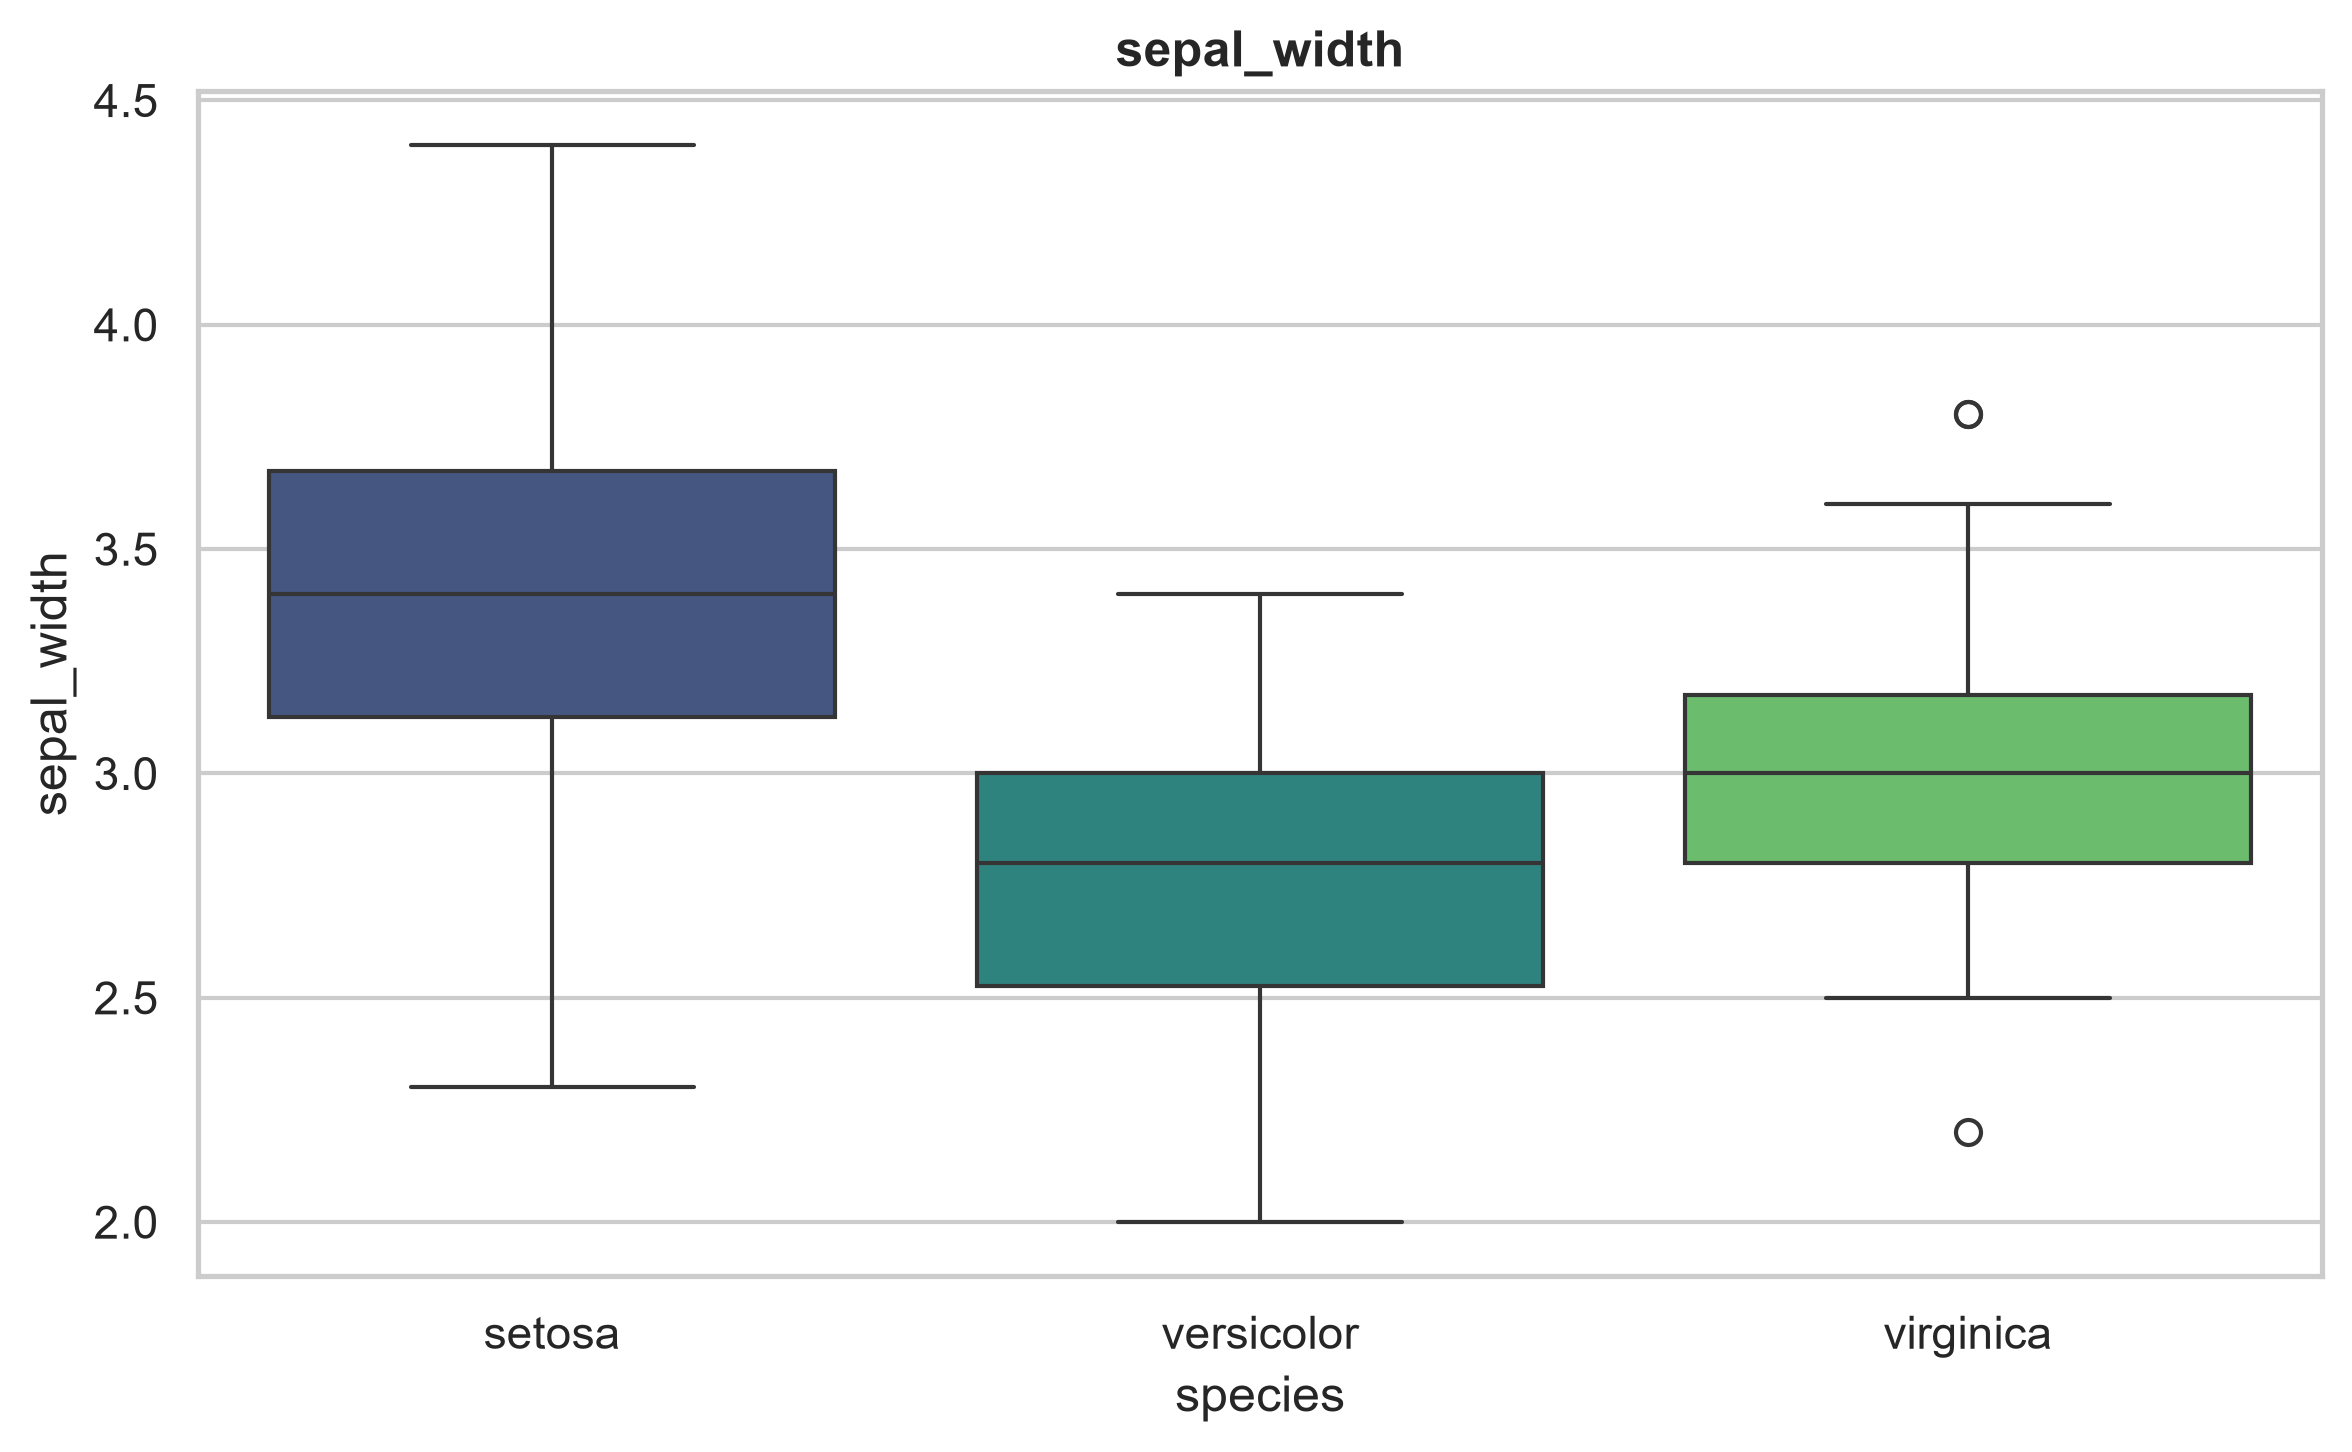

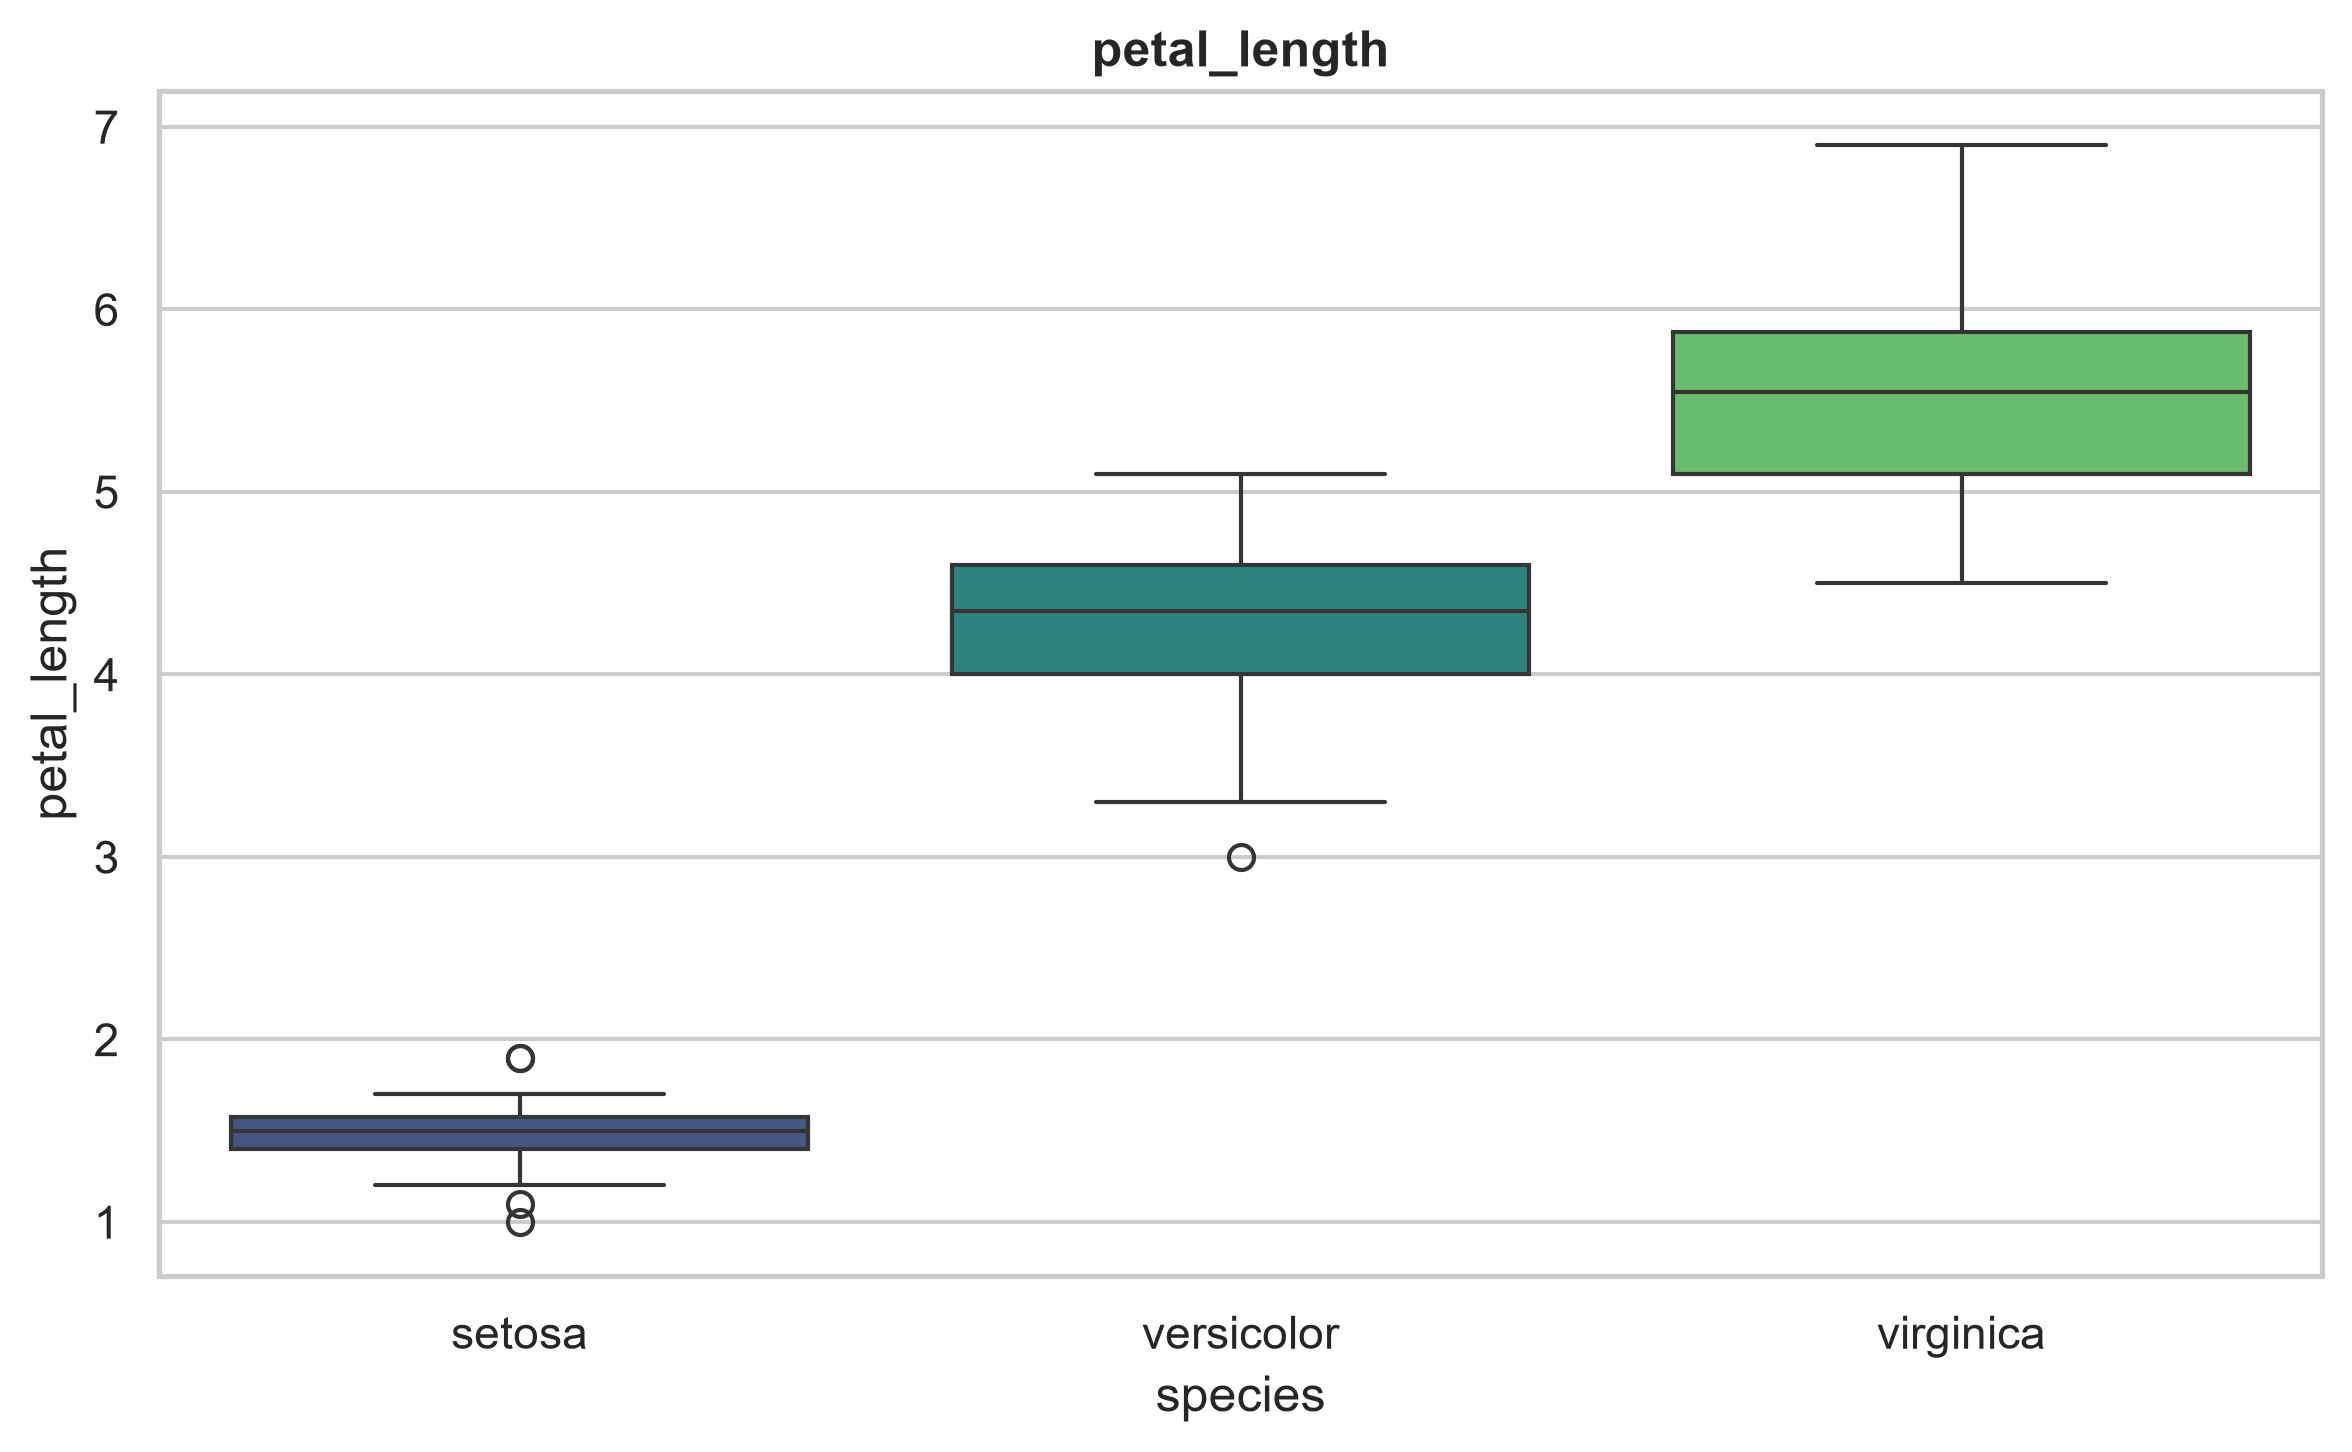

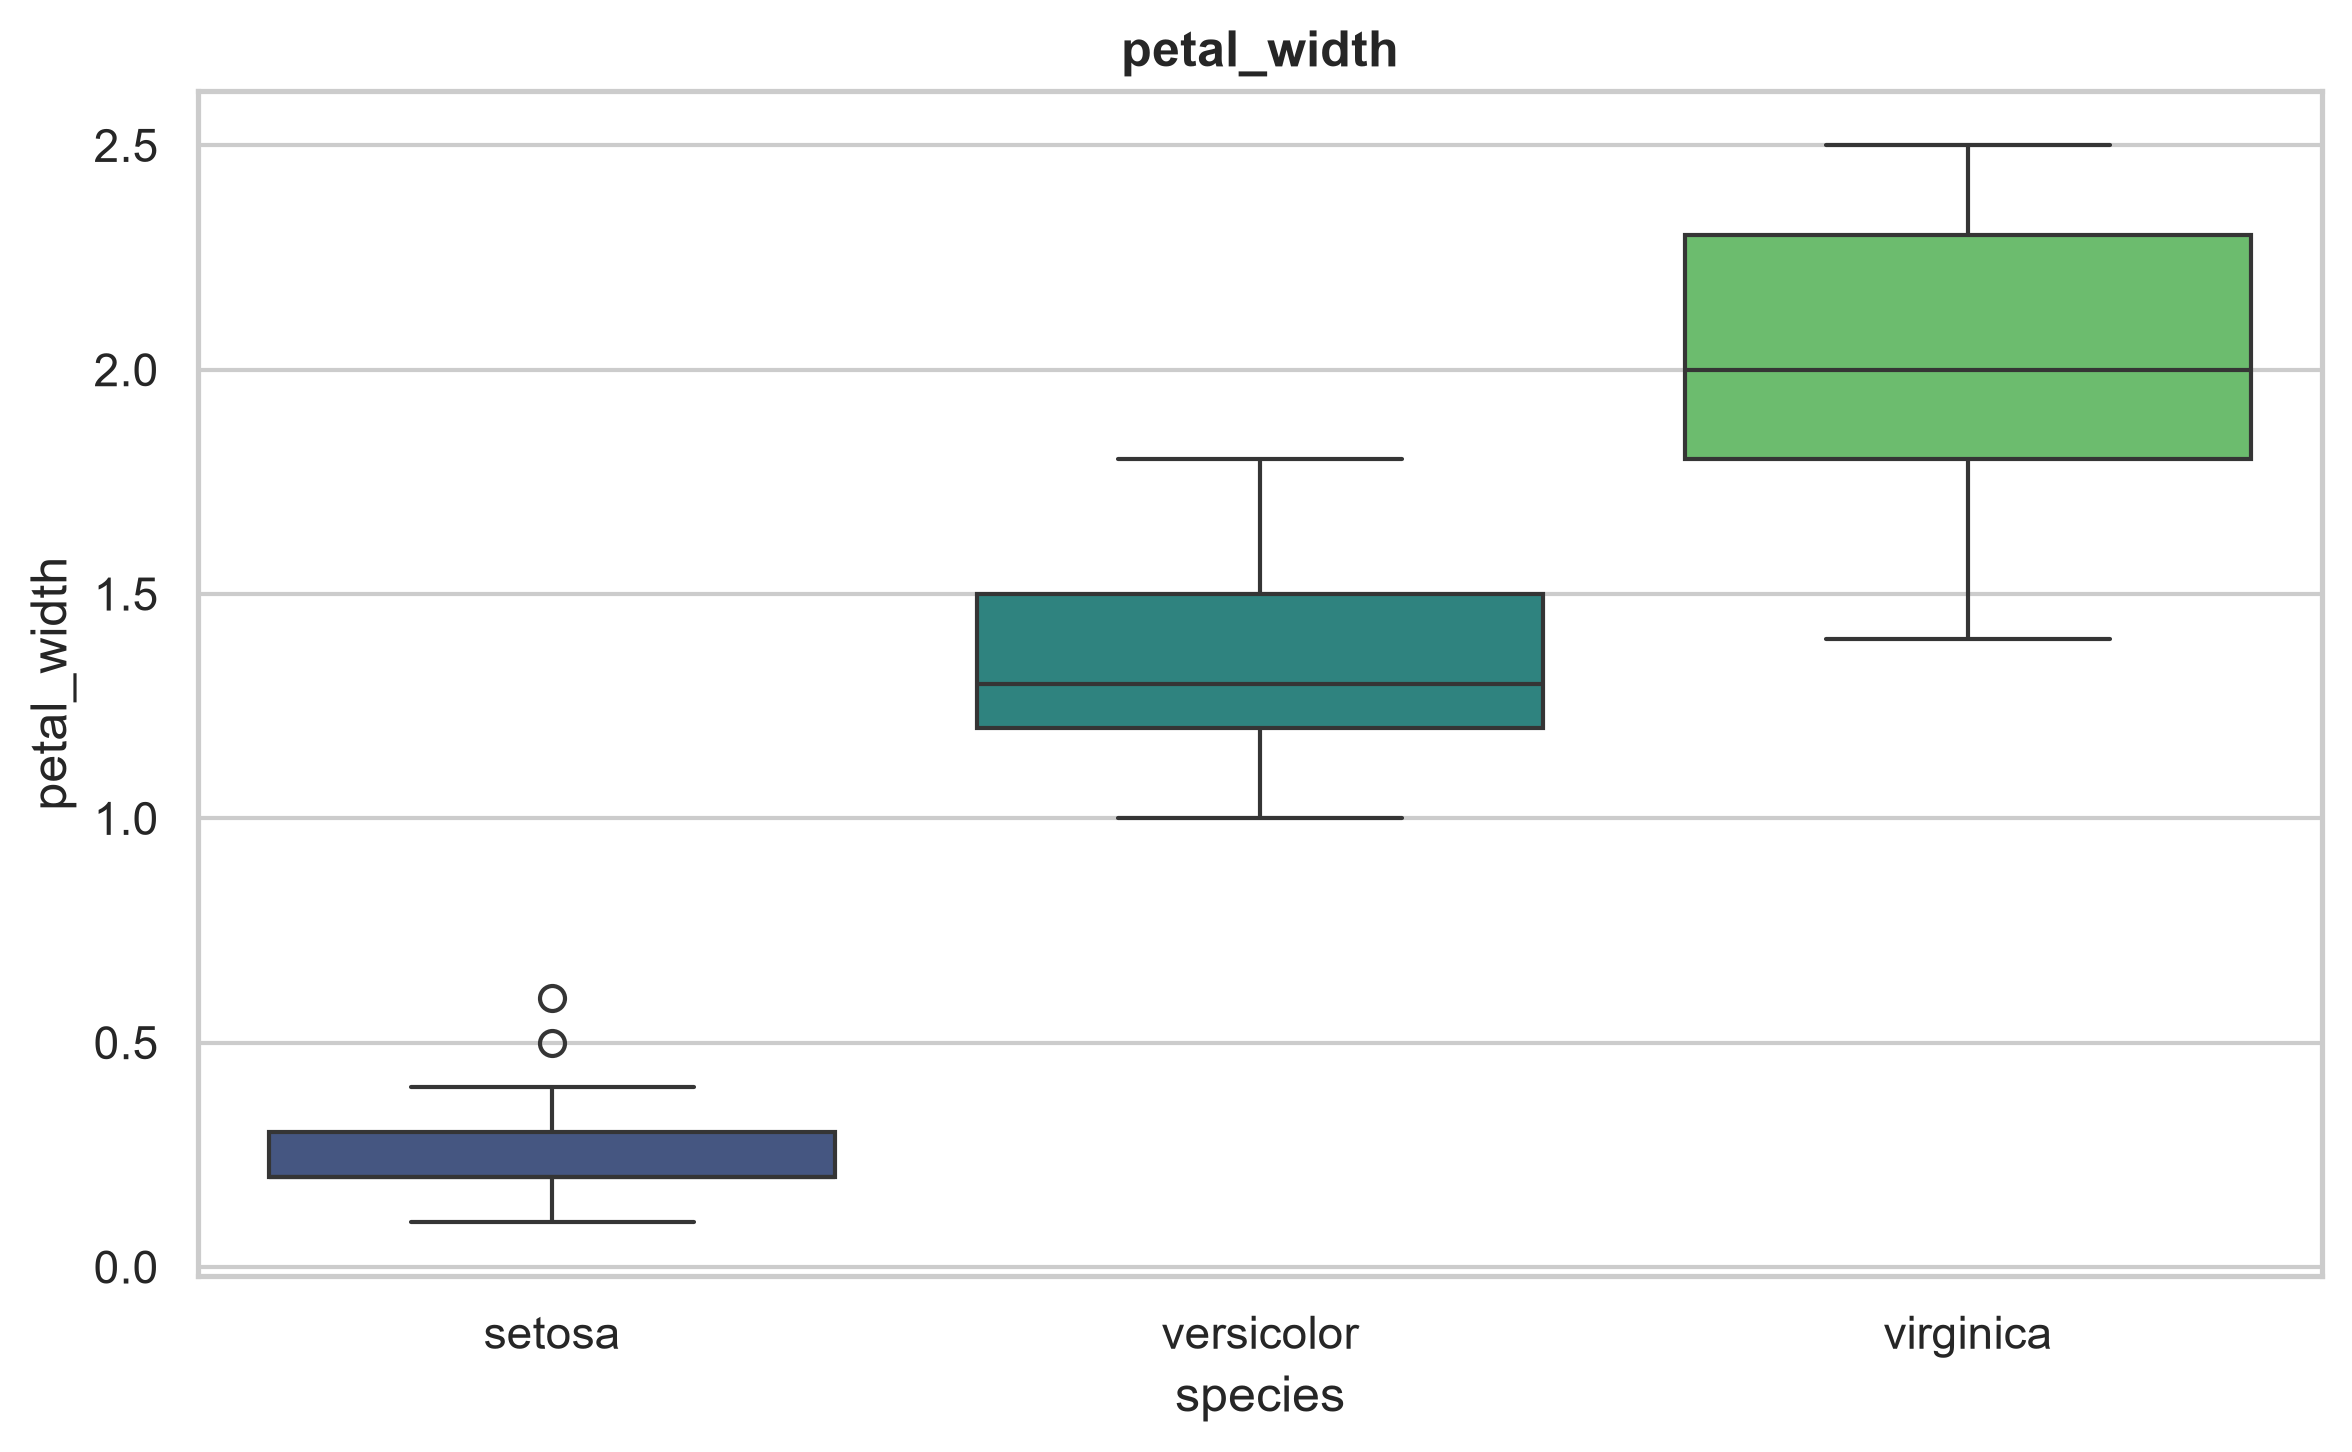

In [11]:
features = data.columns[:-1]

for feature in features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=data,
        x="species",
        y=feature,
        palette="viridis"
    )

    plt.title(feature,fontweight="bold")

    plt.tight_layout()

    plt.savefig(f"../graphs/{feature}_boxplot.png",dpi=300)

    plt.show()

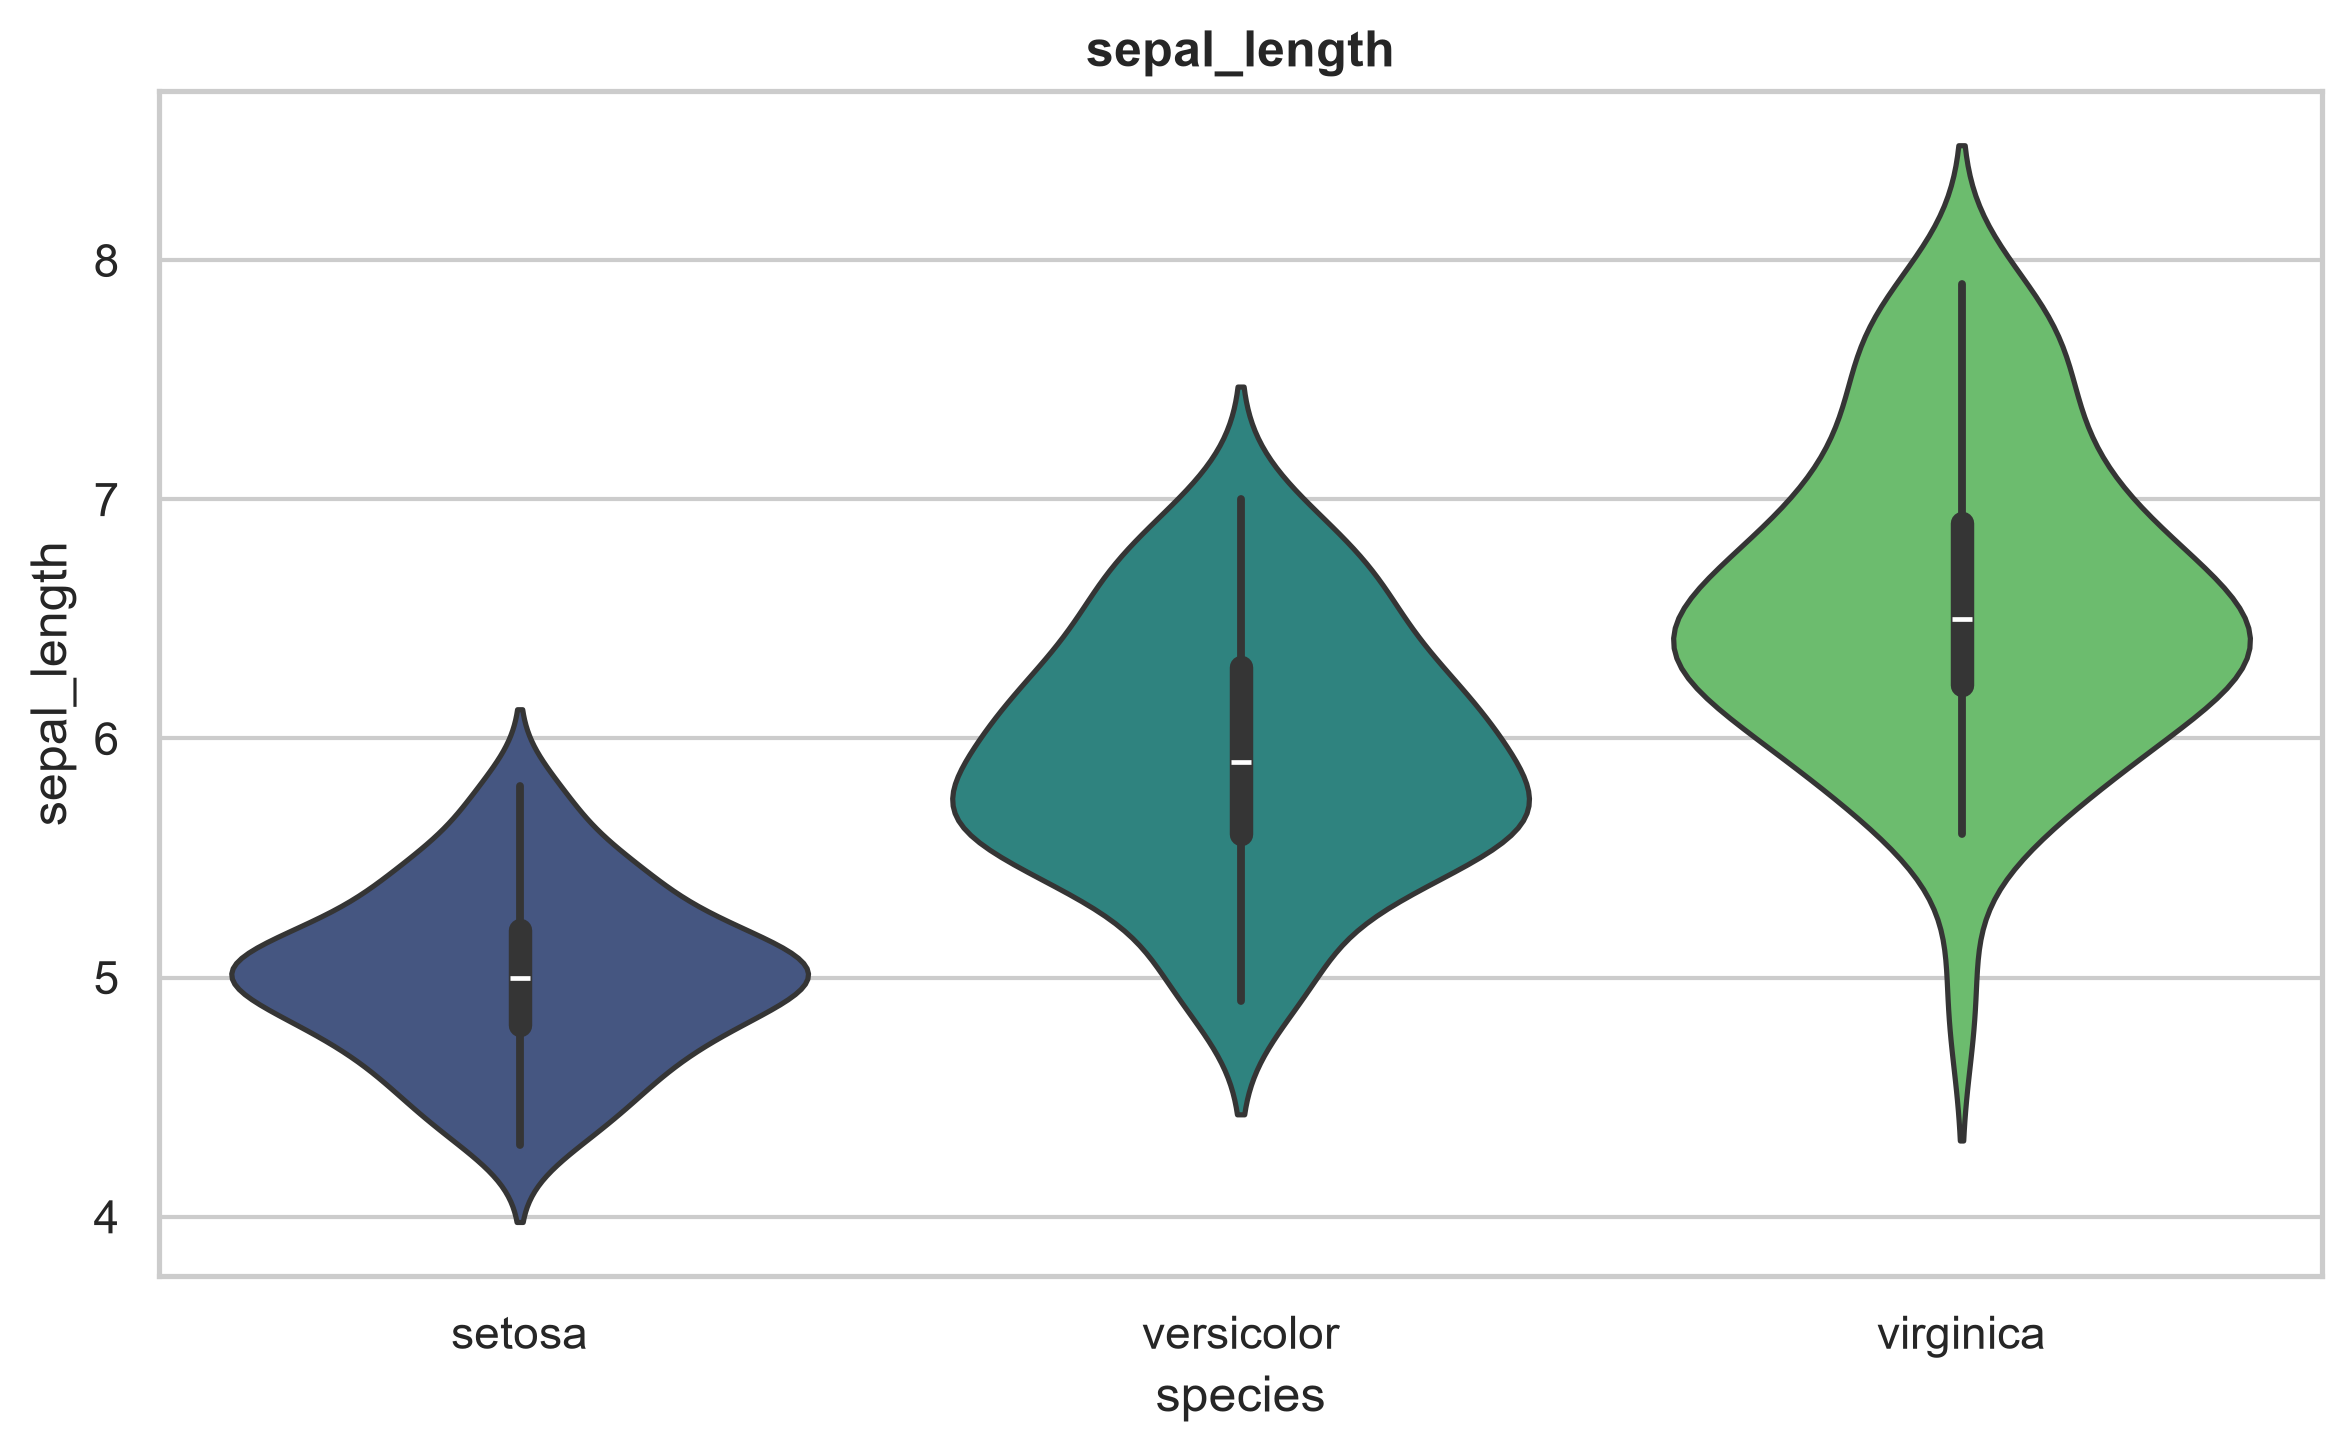

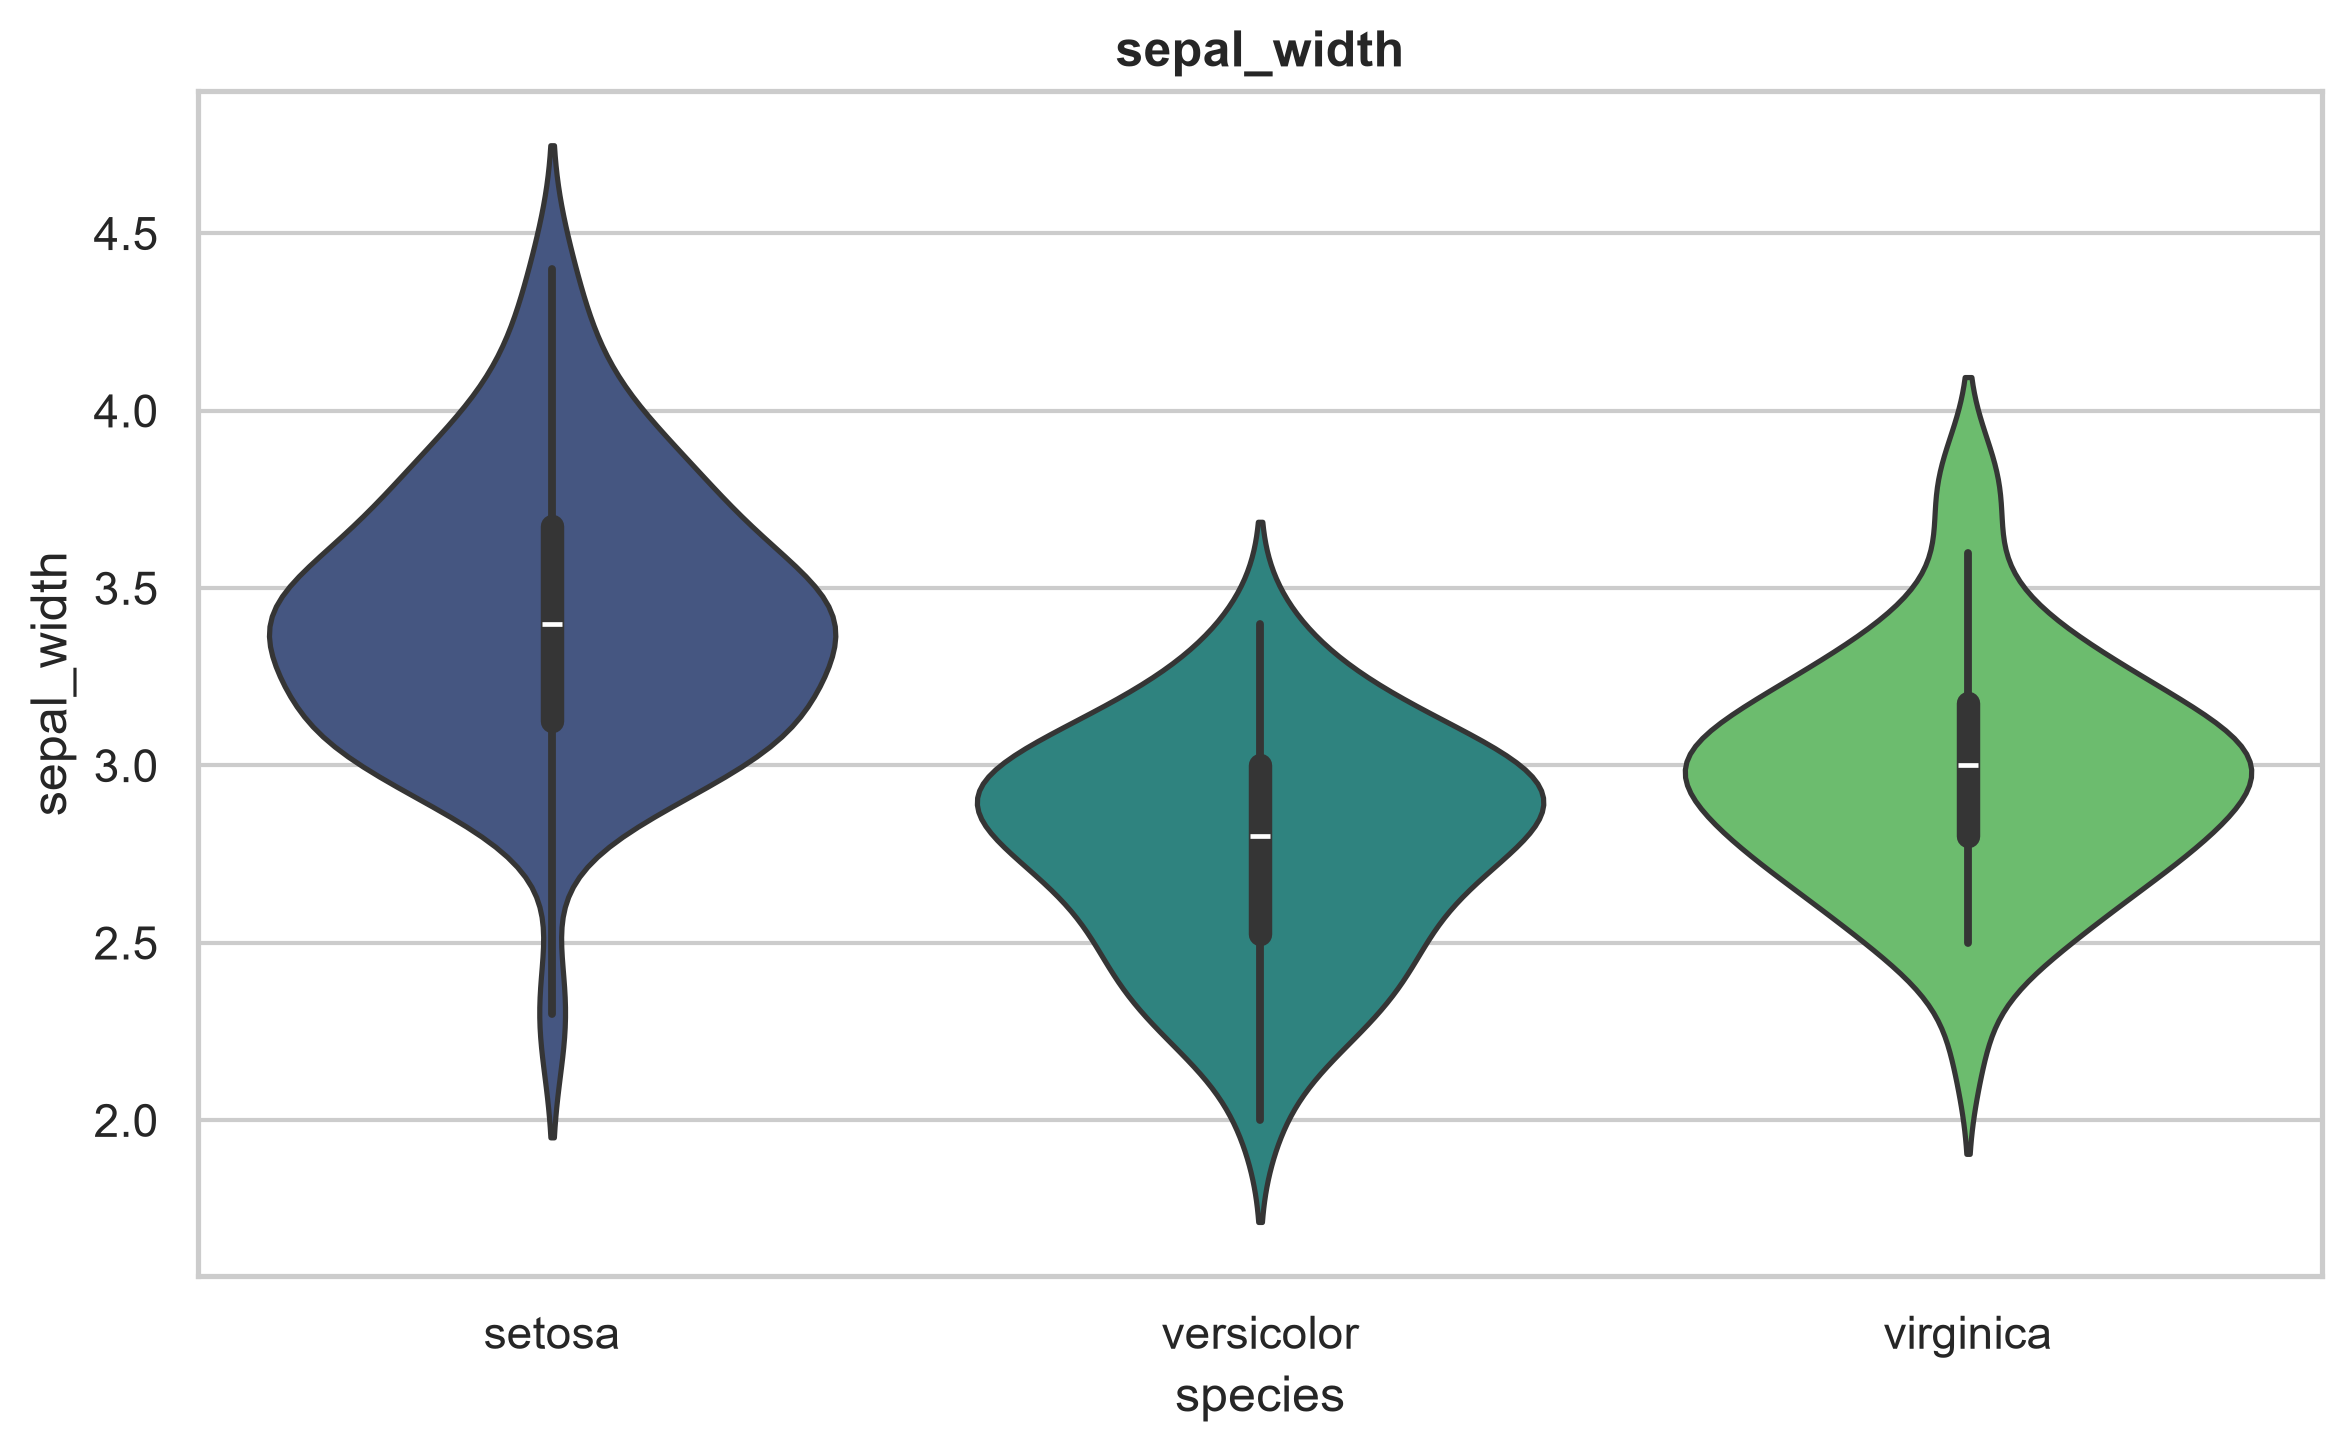

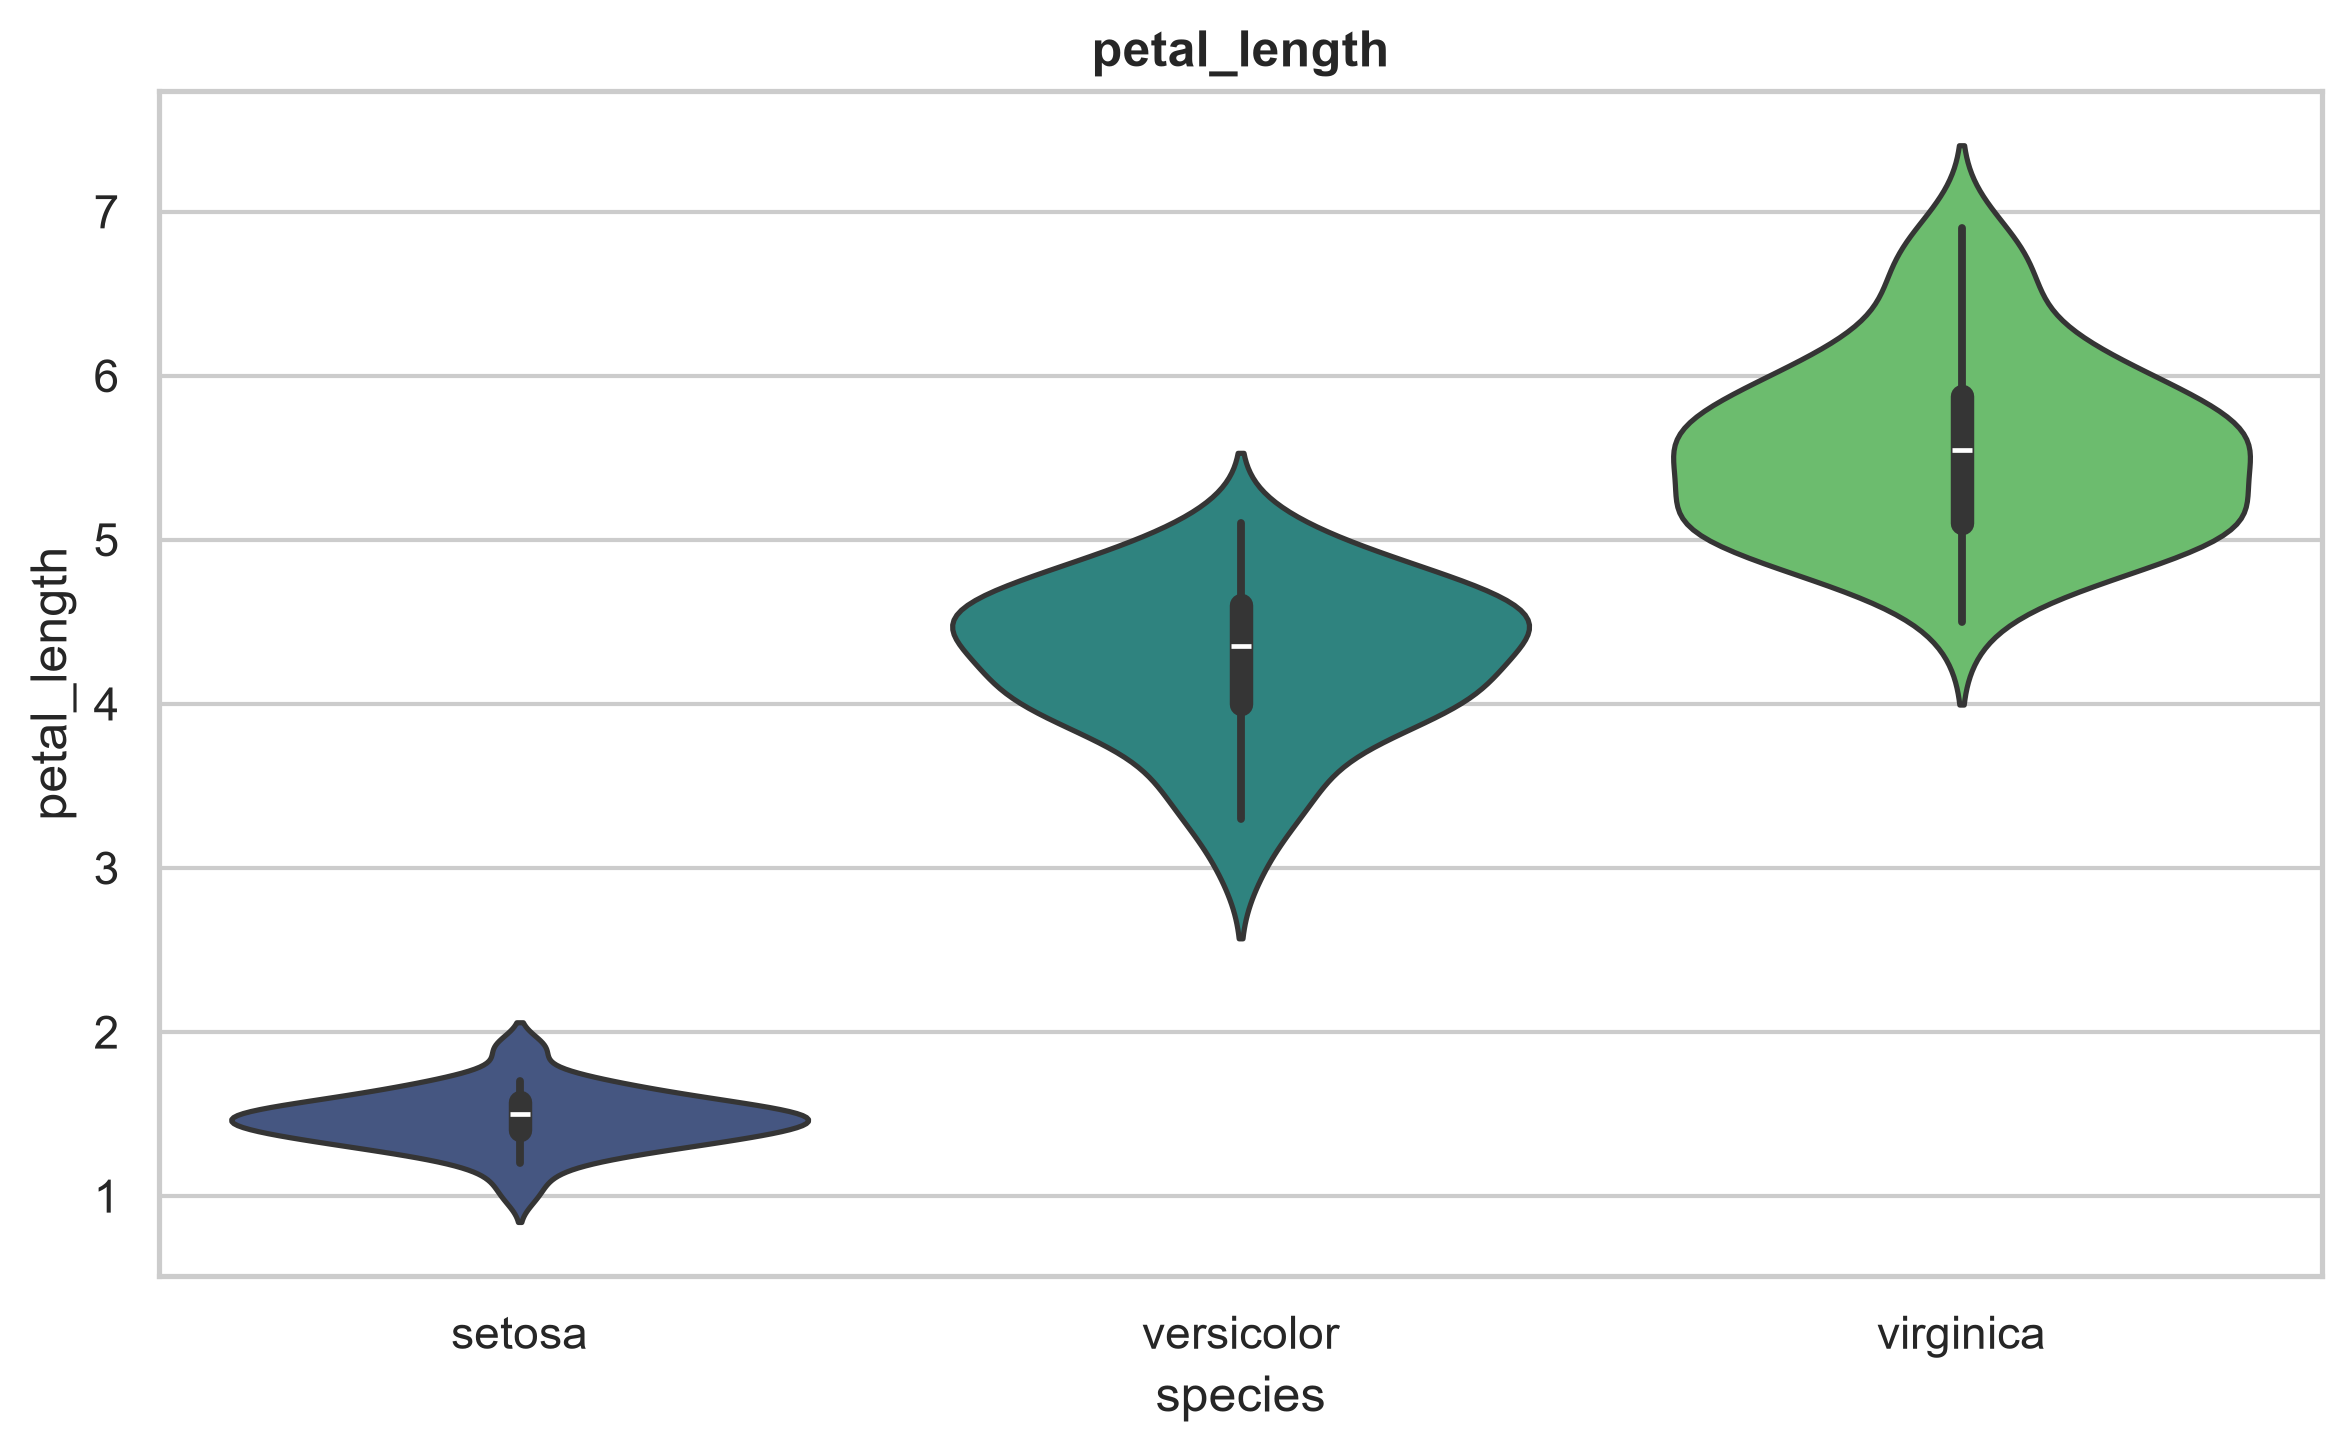

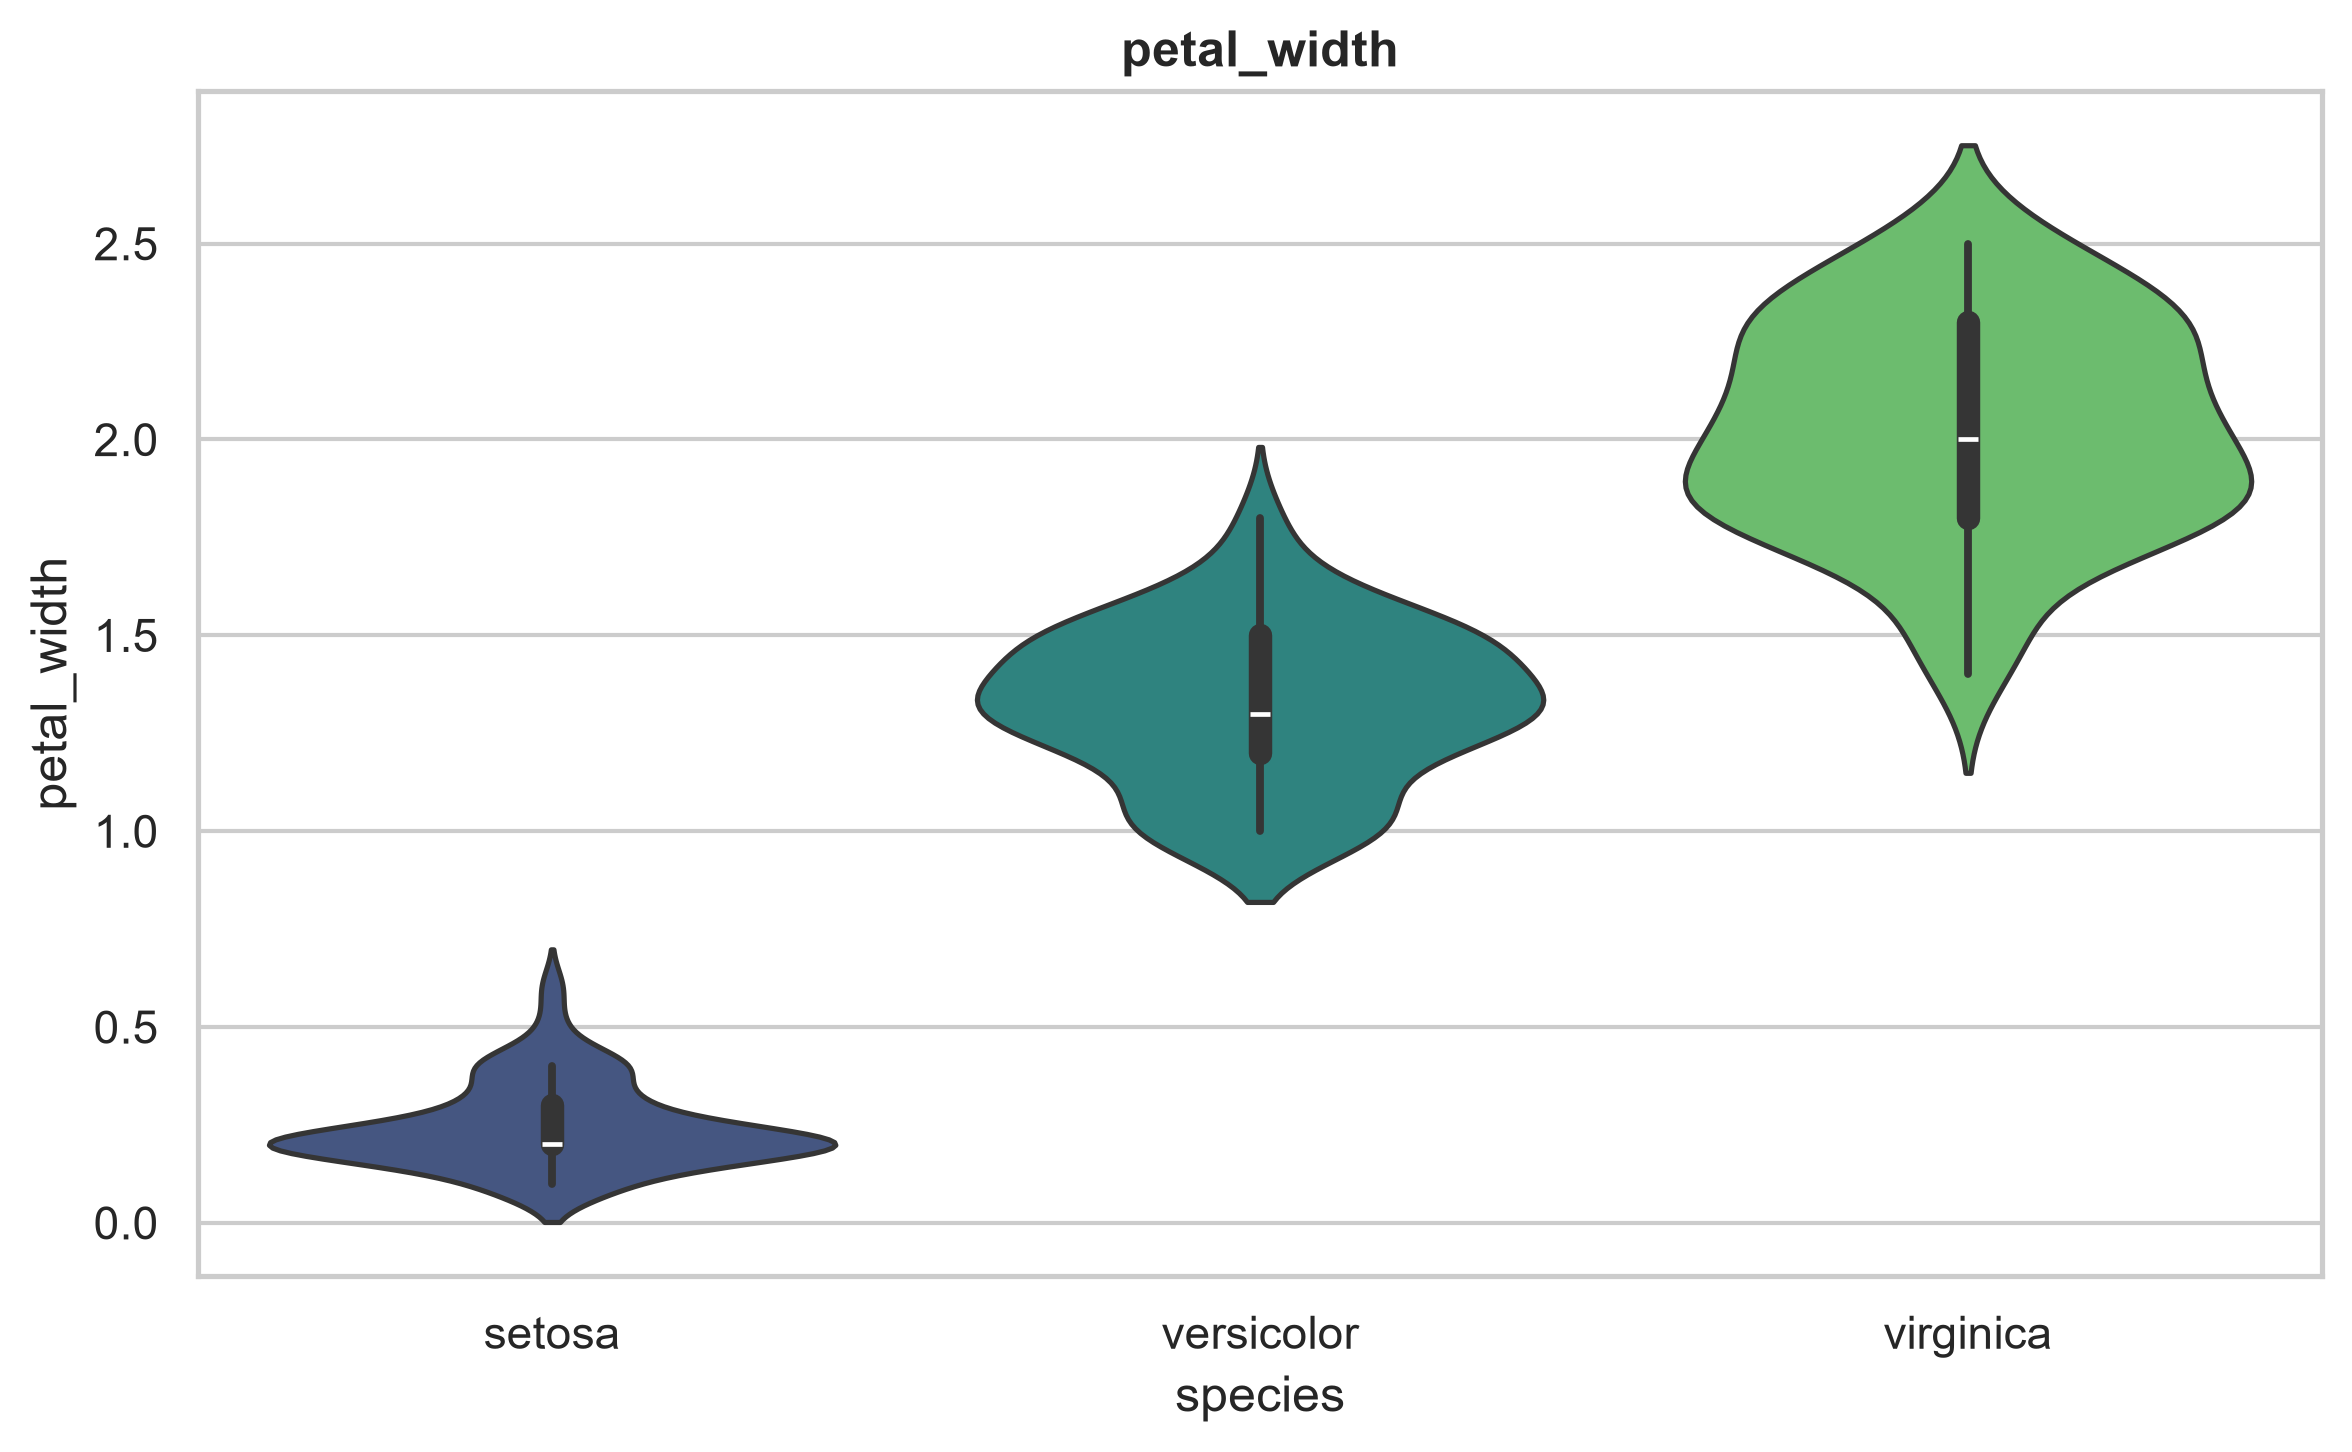

In [12]:
features = data.columns[:-1]

for feature in features:

    plt.figure(figsize=(8,5))

    sns.violinplot(
        data=data,
        x="species",
        y=feature,
        palette="viridis"
    )

    plt.title(feature,fontweight="bold")

    plt.tight_layout()

    plt.savefig(f"../graphs/{feature}_violin.png",dpi=300)

    plt.show()

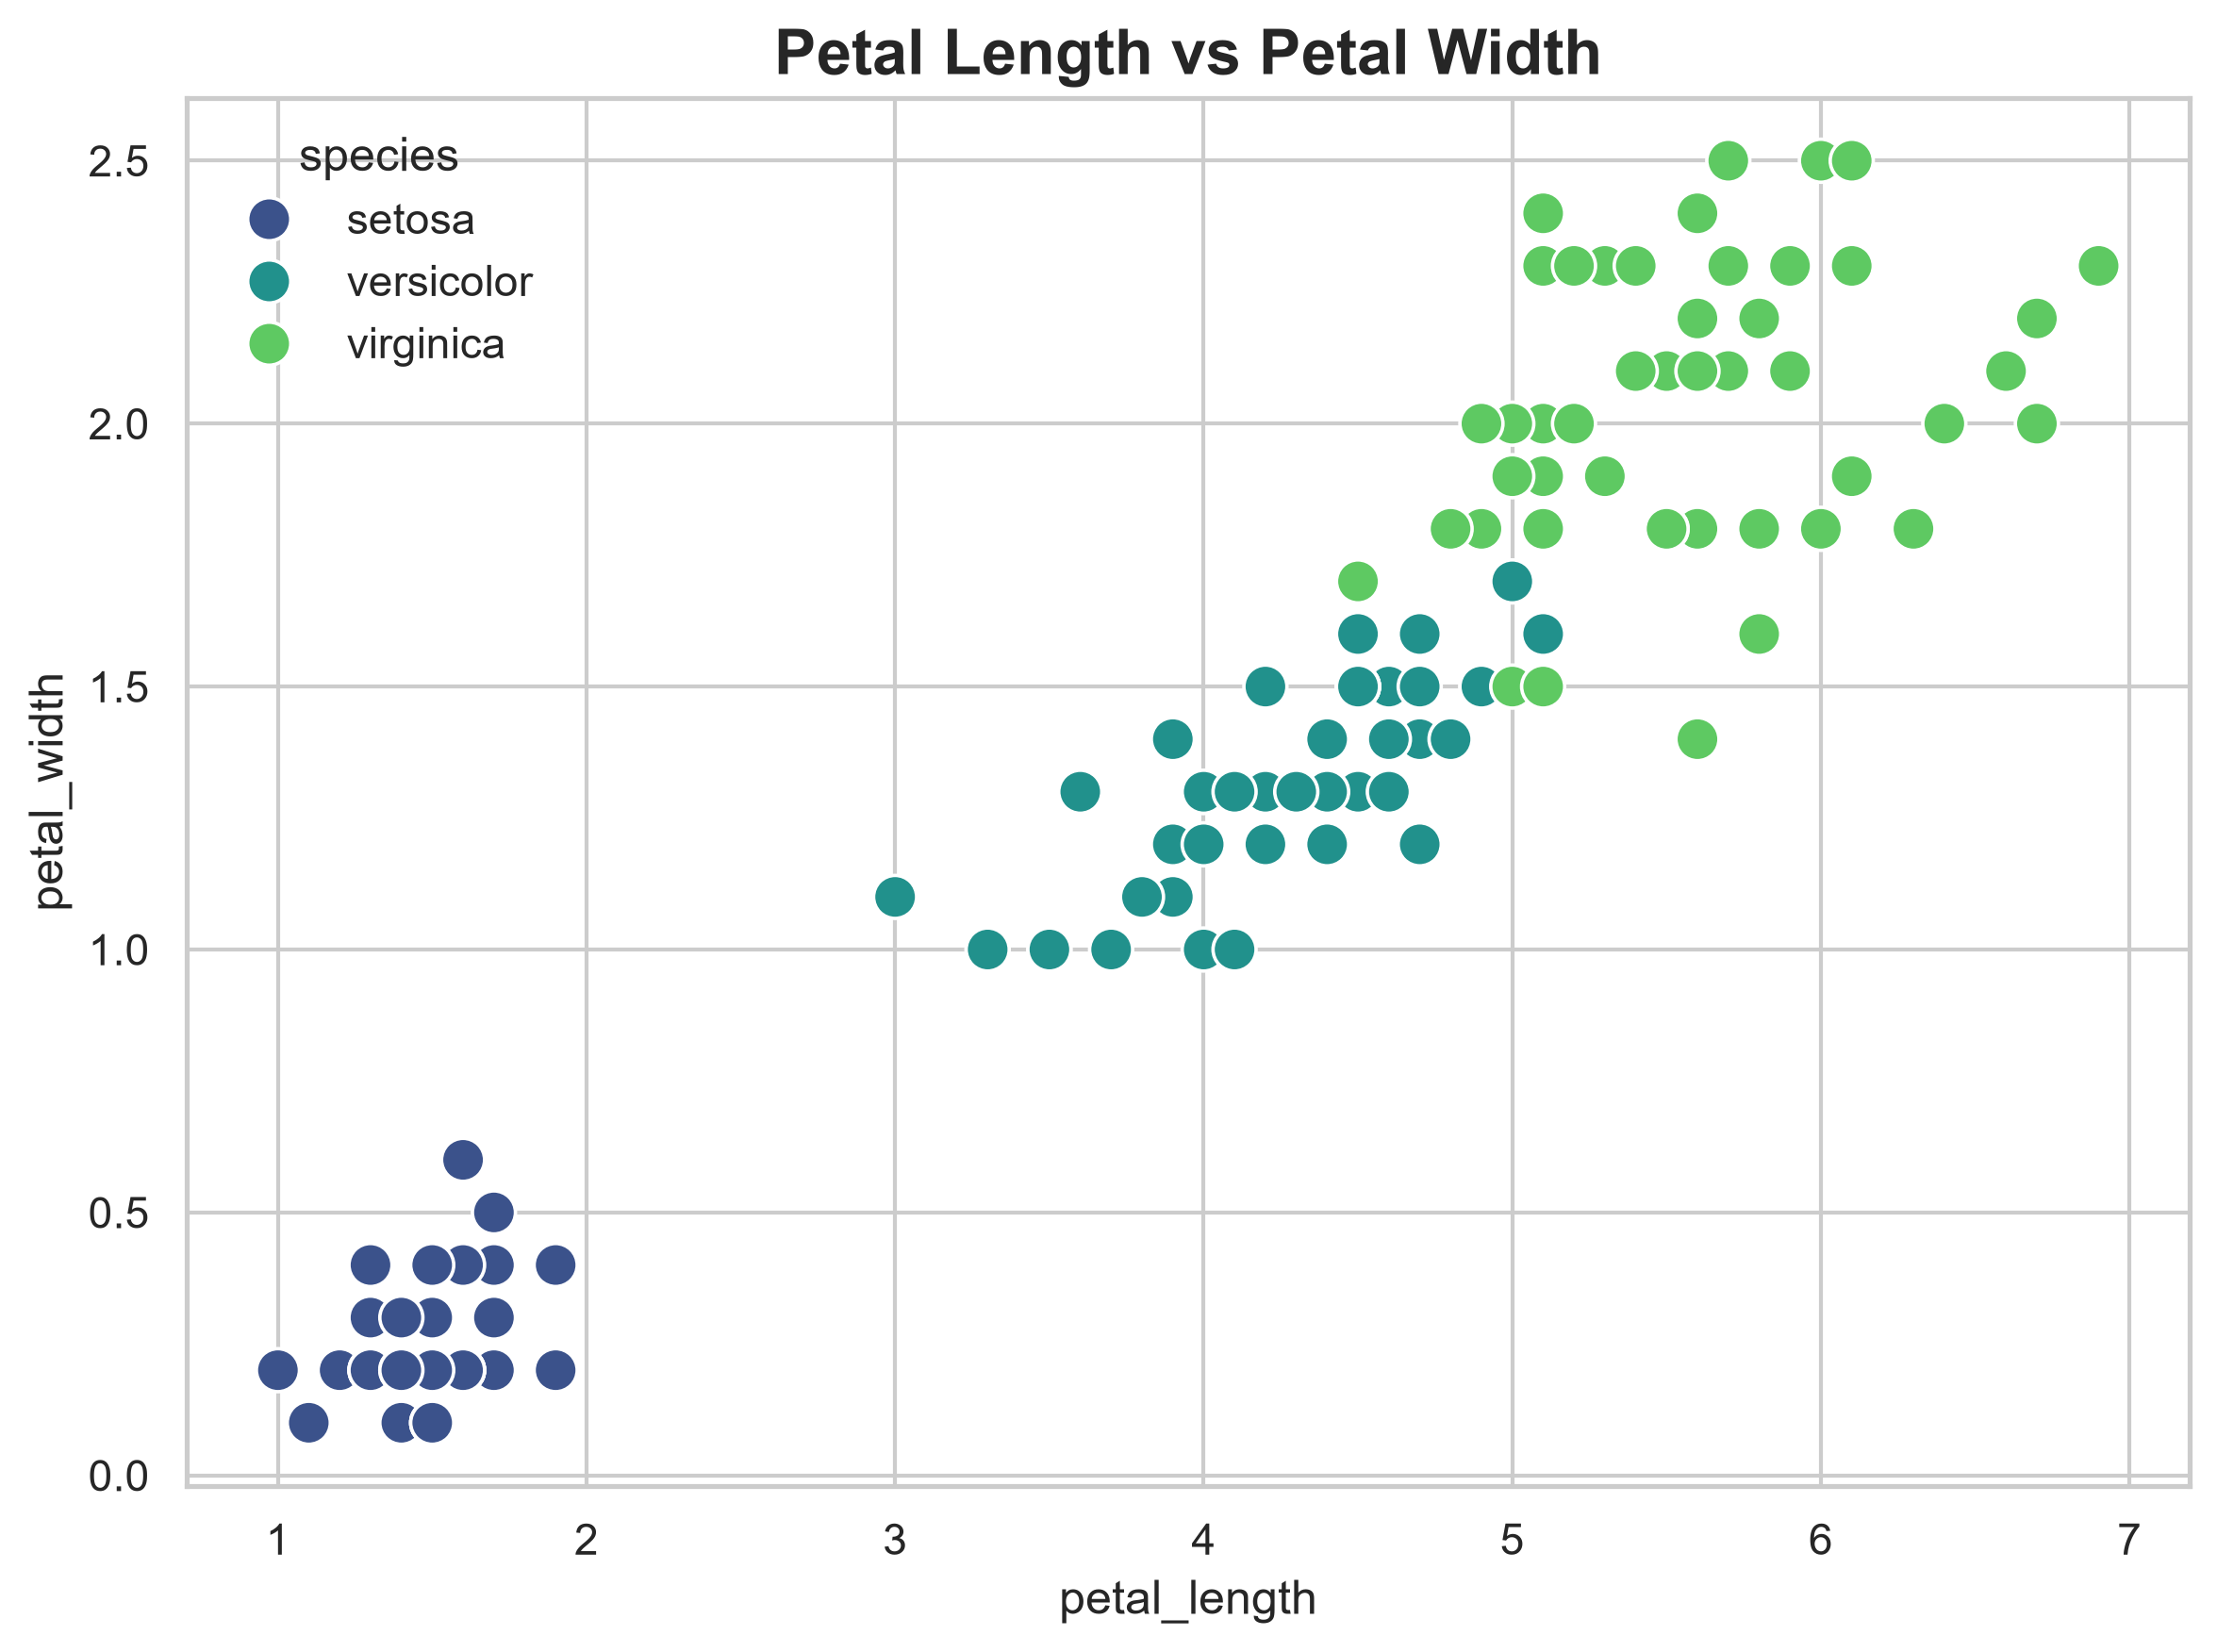

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=data,
    x="petal_length",
    y="petal_width",
    hue="species",
    palette="viridis",
    s=120
)

plt.title(
    "Petal Length vs Petal Width",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig("../graphs/scatter_plot.png",dpi=300)

plt.show()

In [14]:
data.to_csv("../data/iris-cleaned.csv",index=False)

print("Clean Dataset Saved Successfully")

Clean Dataset Saved Successfully


In [22]:
from joblib import load
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create graphs folder
os.makedirs("../graphs", exist_ok=True)

# Load model
model = load("../models/iris_model.pkl")

# Check if model supports feature importance
if hasattr(model, "feature_importances_"):

    feature_importance = pd.DataFrame({
        "Feature": data.columns[:-1],
        "Importance": model.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(9,6))

    sns.barplot(
        data=feature_importance,
        x="Importance",
        y="Feature",
        palette="viridis"
    )

    plt.title(
        "Feature Importance",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.savefig(
        "../graphs/feature_importance.png",
        dpi=300
    )

    plt.show()

else:

    print("Current model does not support feature importance.")

Current model does not support feature importance.


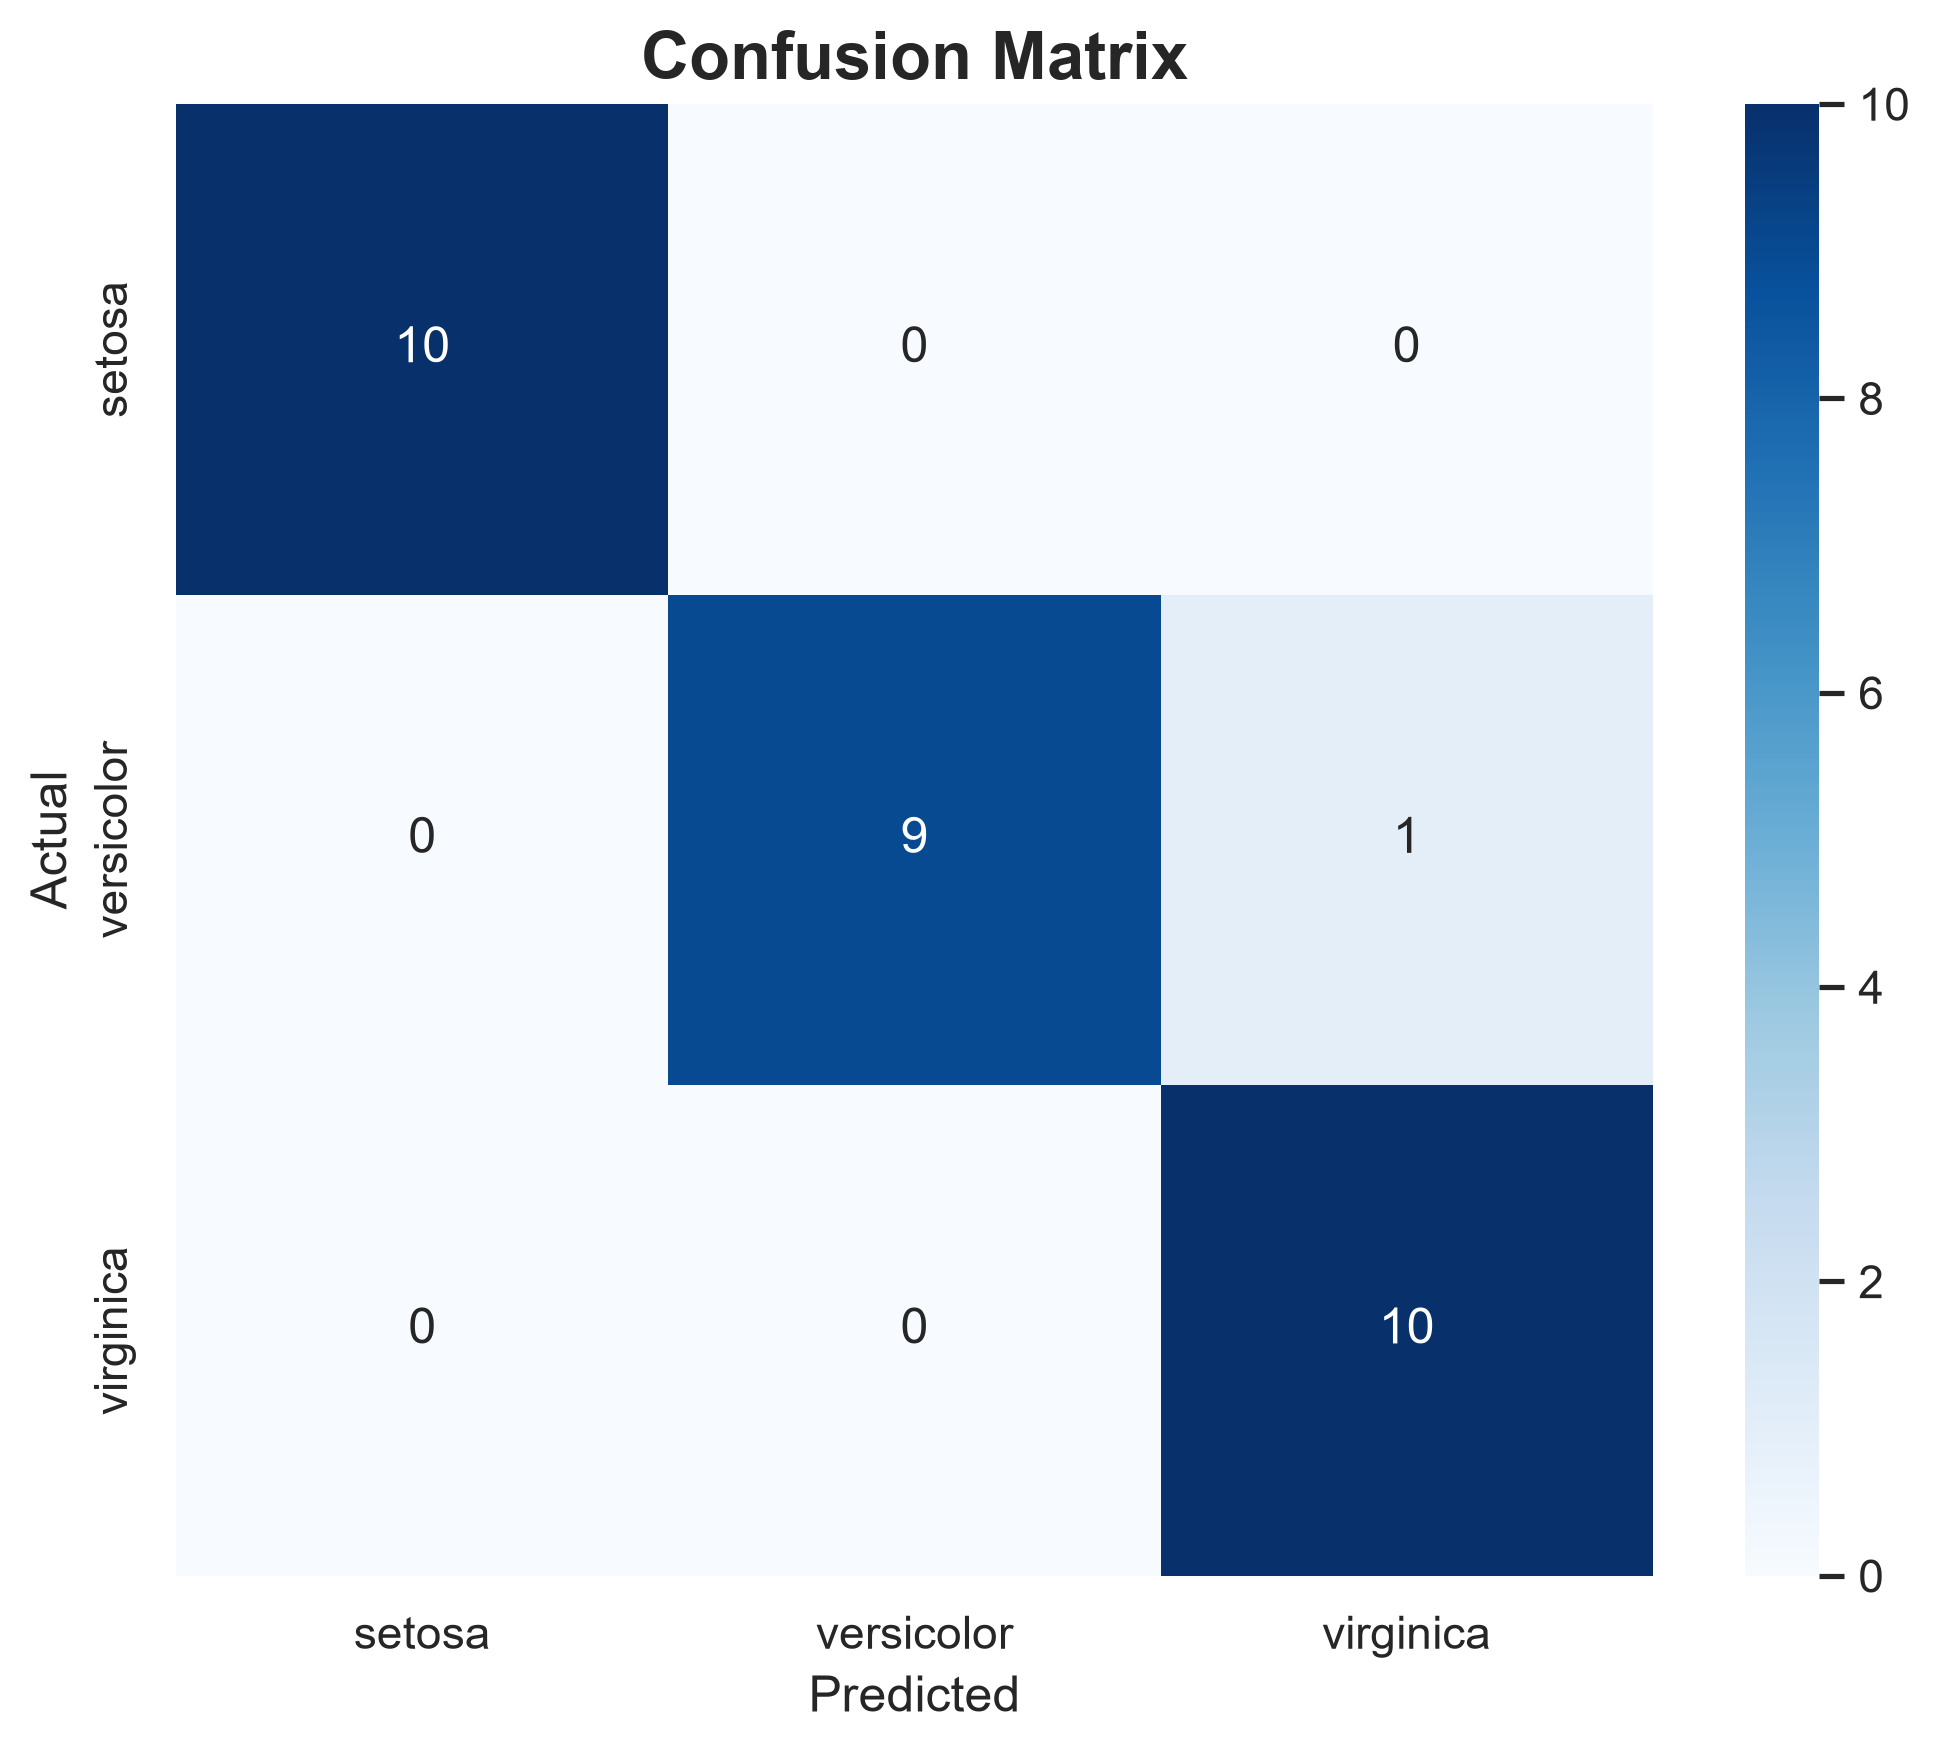

In [23]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

X = data.drop("species", axis=1)
y = data["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

predictions = model.predict(X_test)

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../graphs/confusion_matrix.png",
    dpi=300
)

plt.show()

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("="*50)
print(f"Model Accuracy : {accuracy:.2%}")
print("="*50)

Model Accuracy : 96.67%


In [19]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [20]:
print("="*60)

print("DATASET INSIGHTS")

print("="*60)

print(f"Total Samples : {len(data)}")

print(f"Features : {len(data.columns)-1}")

print(f"Classes : {data['species'].nunique()}")

print("\nSpecies Distribution")

print(data["species"].value_counts())

DATASET INSIGHTS
Total Samples : 150
Features : 4
Classes : 3

Species Distribution
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [21]:
print("="*60)

print("FINAL CONCLUSION")

print("="*60)

print("""

1. Dataset contains three Iris flower species.

2. Dataset is balanced.

3. No significant missing values.

4. Petal Length and Petal Width are
   the most important features.

5. The classification model achieved
   approximately 96–100% accuracy.

6. The trained model can accurately
   predict unseen Iris flower species.

7. This project demonstrates the
   complete Machine Learning workflow:

   ✔ Data Collection

   ✔ Data Cleaning

   ✔ Exploratory Data Analysis

   ✔ Visualization

   ✔ Model Training

   ✔ Model Evaluation

   ✔ Prediction

   ✔ Model Saving

""")

FINAL CONCLUSION


1. Dataset contains three Iris flower species.

2. Dataset is balanced.

3. No significant missing values.

4. Petal Length and Petal Width are
   the most important features.

5. The classification model achieved
   approximately 96–100% accuracy.

6. The trained model can accurately
   predict unseen Iris flower species.

7. This project demonstrates the
   complete Machine Learning workflow:

   ✔ Data Collection

   ✔ Data Cleaning

   ✔ Exploratory Data Analysis

   ✔ Visualization

   ✔ Model Training

   ✔ Model Evaluation

   ✔ Prediction

   ✔ Model Saving


